## Configuración:
* Importación Librerias
* Definición rutas
* Definición funciones auxiliares

In [27]:
# Reload modulos automaticamente
%load_ext autoreload
%autoreload 2

from modules.gnn_models import GCN, GraphSAGE, GAT
from modules.graph import Graph
from modules.gnn import GNN
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.metrics import roc_auc_score
import torch.nn.functional as F
import numpy as np
from collections import Counter

import torch
import numpy as np
from modules.gnn import GNN
from modules.gnn_models import GCN, GraphSAGE, GAT
import dgl
import torch
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

import torch.nn as nn
import torch.nn.functional as F
import dgl.function as fn
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os
from dgl.nn import DeepWalk
from torch.utils.data import DataLoader
from torch.optim import SparseAdam
from sklearn.metrics import roc_auc_score
from modules.gnn_models import GCNSampler, GraphSAGESample, GATSample
from sklearn.metrics import mean_absolute_error, r2_score
import gensim
from modules.bgp2vec import BGP2VEC
from gensim.models import Word2Vec


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Aprender Embeddings

In [6]:
from pathlib import Path

# Archivos del nuevo formato de grafo (nodos/aristas)
data_path = "/media/vale/KINGSTON/TESIS/data_2026/"
nodes_file = data_path + "/nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv"
edges_file = data_path + "/edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv"

ribs_file = data_path + "/rib_20260301_0000_to_20260302_0000.txt"
if not Path(nodes_file).exists():
    raise FileNotFoundError(f"No existe el archivo de nodos: {nodes_file}")
if not Path(edges_file).exists():
    raise FileNotFoundError(f"No existe el archivo de aristas: {edges_file}")
if not Path(ribs_file).exists():
    raise FileNotFoundError(f"No existe el archivo de RIBs: {ribs_file}")

print(f"Nodos: {nodes_file}")
print(f"Aristas: {edges_file}")

Nodos: /media/vale/KINGSTON/TESIS/data_2026//nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv
Aristas: /media/vale/KINGSTON/TESIS/data_2026//edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv


## Funciones Auxiliares

In [7]:
def compute_auc(pos_score, neg_score):
    pos_score = pos_score.squeeze(-1) if pos_score.dim() > 1 else pos_score
    neg_score = neg_score.squeeze(-1) if neg_score.dim() > 1 else neg_score
    scores = torch.cat([pos_score, neg_score]).numpy()
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])]).numpy()
    return roc_auc_score(labels, scores)


def compute_loss(pos_score, neg_score):
    pos_score = pos_score.squeeze(-1) if pos_score.dim() > 1 else pos_score
    neg_score = neg_score.squeeze(-1) if neg_score.dim() > 1 else neg_score
    scores = torch.cat([pos_score, neg_score])
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])])
    return F.binary_cross_entropy_with_logits(scores, labels)


def compute_accuracy(pos_score, neg_score, threshold=0.5):
    pos_score = pos_score.squeeze(-1) if pos_score.dim() > 1 else pos_score
    neg_score = neg_score.squeeze(-1) if neg_score.dim() > 1 else neg_score
    scores = torch.cat([pos_score, neg_score])
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])])
    preds = (scores > threshold).float()
    acc = (preds == labels).sum().item() / len(labels)
    print(f'Accuracy: {acc:.4f} (Threshold: {threshold:.2f})')
    return acc


def plot_roc_with_distributions(pos_score, neg_score, model_name, caso):
    pos_score = pos_score.squeeze(-1) if pos_score.dim() > 1 else pos_score
    neg_score = neg_score.squeeze(-1) if neg_score.dim() > 1 else neg_score
    scores = torch.cat([pos_score, neg_score]).numpy()
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])]).numpy()
    fpr, tpr, thresholds = roc_curve(labels, scores)
    auc = roc_auc_score(labels, scores)
    distances = np.sqrt((1 - tpr) ** 2 + fpr ** 2)
    optimal_idx = np.argmin(distances)
    optimal_threshold = thresholds[optimal_idx]
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].hist(pos_score.numpy(), bins=50, alpha=0.5, label='Positivos', color='skyblue')
    ax[0].hist(neg_score.numpy(), bins=50, alpha=0.5, label='Negativos', color='salmon')
    ax[0].axvline(x=optimal_threshold, color='red', linestyle='--',
                  label=f'Umbral={optimal_threshold:.3f}')
    ax[0].set_xlabel('Score'); ax[0].set_ylabel('Frecuencia')
    ax[0].set_title(f'Distribución de Scores: {model_name}'); ax[0].legend()
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={auc:.4f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    ax[1].scatter([fpr[optimal_idx]], [tpr[optimal_idx]], color='red', zorder=5,
                  label='Umbral optimo')
    ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR')
    ax[1].set_title(f'Curva ROC - {caso}: {model_name}'); ax[1].legend(loc='lower right')
    plt.tight_layout()
    save_dir = data_path + f'results/EnfoquePorPartes/{caso}'
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f'{save_dir}/roc_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return optimal_threshold


def plot_loss_evolution(train_losses, num_epochs=None, title='Loss Evolution',
                        val_losses=None, test_losses=None):
    secondary = val_losses if val_losses is not None else test_losses
    ep = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(ep, train_losses, label='Train Loss', linewidth=1.5)
    if secondary is not None:
        plt.plot(ep, secondary[:len(train_losses)], label='Val Loss', linewidth=1.5)
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(title)
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## Casos


### Caso 0: Predicción de enlaces utilizando grafo con atributos de nodos extraídos de Peerin

In [12]:
models = {
    'GCN': GCN,
    'GraphSAGE': GraphSAGE,
    'GAT': GAT,
}

NUM_EPOCHS = 100
LEARNING_RATE = 0.01
BATCH_SIZE = 1024
WEIGHT_DECAY = 5e-4
PATIENCE = 20


In [10]:
# 1. Cargar datos con el nuevo formato (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))


gnn.split_edges_link_prediction(0.8)


g0 = gnn.dgl_graph
print("\n[Resumen grafo cargado]")
print(f"- Nodos: {g0.num_nodes():,}")
print(f"- Aristas: {g0.num_edges():,}")
print(f"- Dimensión de features: {g0.ndata['feat'].shape[1]}")
print(f"- Edges data keys: {list(g0.edata.keys())}")
# print(f"- Train edges: {g0.edata['train_mask'].sum().item():,}")
# print(f"- Val edges: {g0.edata['val_mask'].sum().item():,}")
# print(f"- Test edges: {g0.edata['test_mask'].sum().item():,}")
# if "label" in g0.edata:
#     print(f"- Distribución de label (global): {Counter(g0.edata['label'].tolist())}")
#     tr = g0.edata['label'][g0.edata['train_mask']]
#     va = g0.edata['label'][g0.edata['val_mask']]
#     te = g0.edata['label'][g0.edata['test_mask']]
#     print(f"- Distribución train: {Counter(tr.tolist())}")
#     print(f"- Distribución val:   {Counter(va.tolist())}")
#     print(f"- Distribución test:  {Counter(te.tolist())}")

Grafo cargado: 79504 nodos, 734381 aristas
Dimensión de entrada (in_feats): 72
[split_basic] +pos train=587504  +pos test=146877
[split_basic] -neg train=587504 -neg test=146877

[Resumen grafo cargado]
- Nodos: 79,504
- Aristas: 734,381
- Dimensión de features: 72
- Edges data keys: ['label']


Encoder: GNN + Decoder: DotProduct


Training model: GCN [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=5.8004  val=0.6415
  Epoch  10: train=1.8953  val=1.4387
  Epoch  20: train=1.4120  val=1.8149
  Early stopping epoch 21. Best val loss: 0.5520


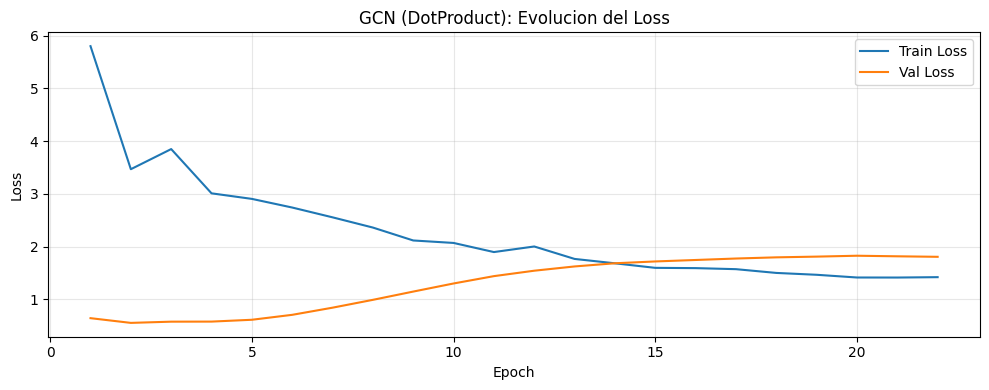

AUC: 0.9362429125727907


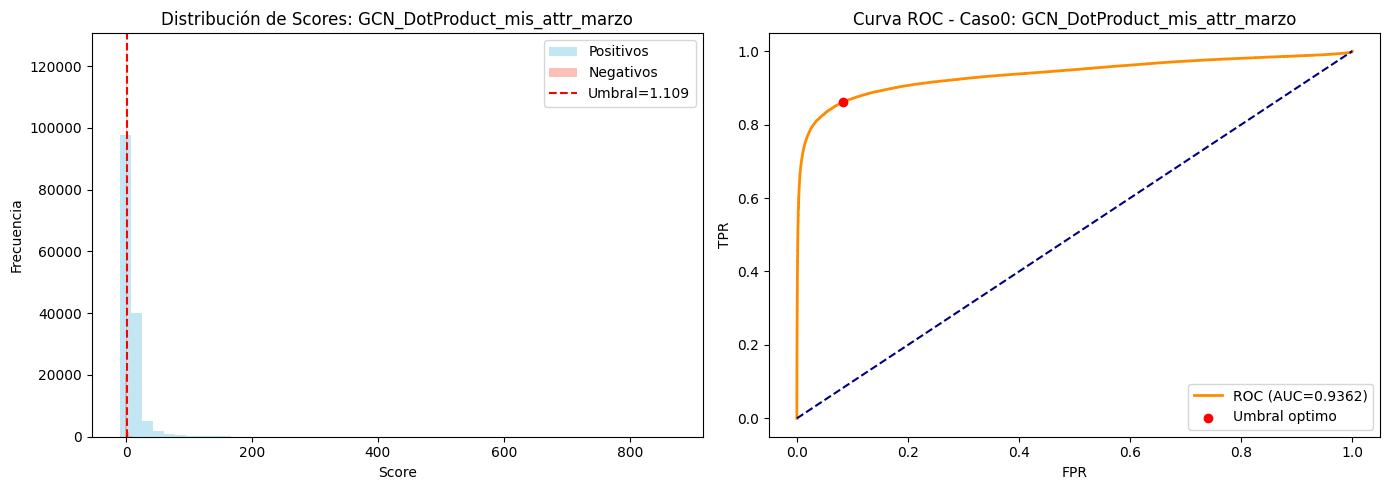

Accuracy: 0.8891 (Threshold: 1.11)


Training model: GraphSAGE [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=2.2386  val=9.4880
  Epoch  10: train=0.9827  val=1.0335
  Epoch  20: train=0.7710  val=0.7508
  Epoch  30: train=0.6802  val=0.6608
  Epoch  40: train=0.6315  val=0.5987
  Epoch  50: train=0.5917  val=0.5798
  Epoch  60: train=0.5697  val=0.5666
  Epoch  70: train=0.5447  val=0.5580
  Epoch  80: train=0.5278  val=0.5510
  Epoch  90: train=0.5191  val=0.5442


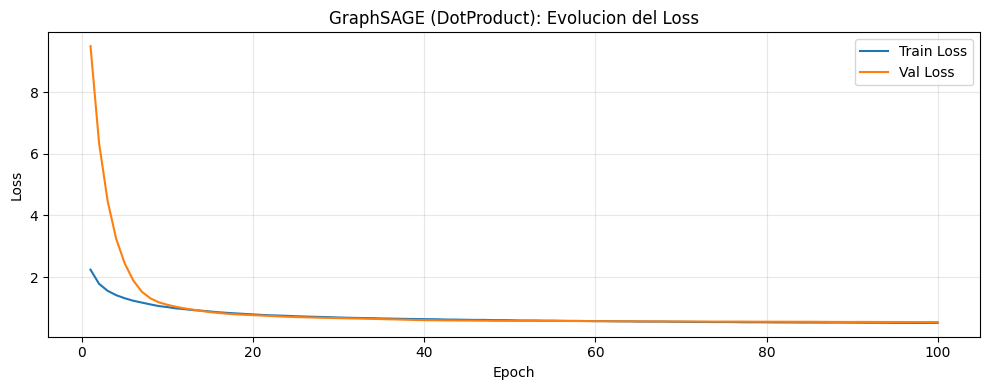

AUC: 0.8753353349268056


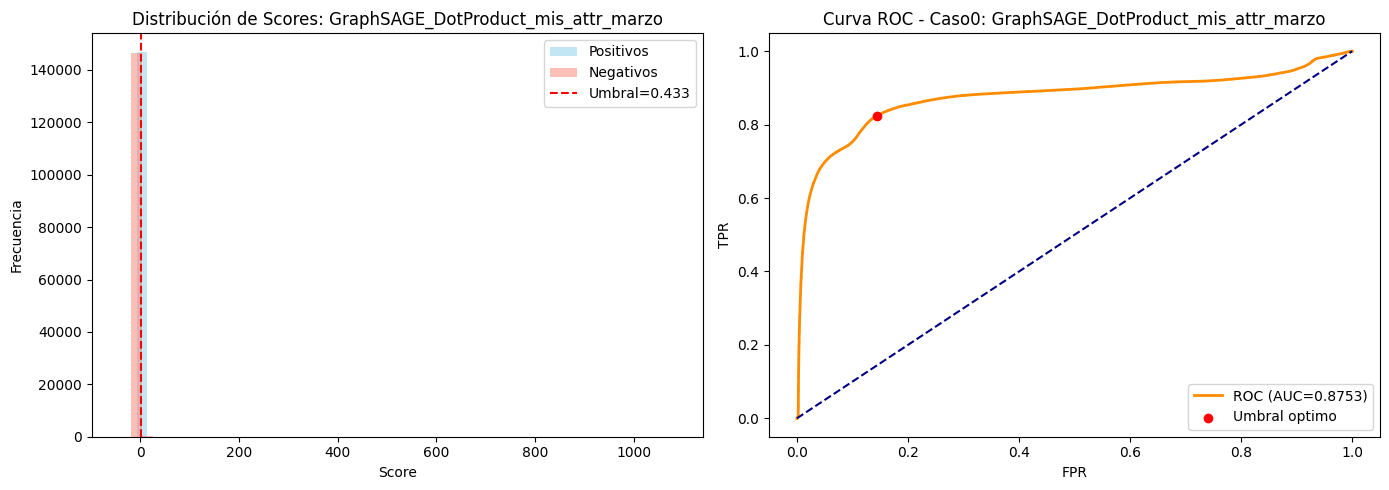

Accuracy: 0.8400 (Threshold: 0.43)


Training model: GAT [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=4.8995  val=2.5872
  Epoch  10: train=0.8431  val=0.7114
  Epoch  20: train=0.7375  val=0.7234
  Early stopping epoch 29. Best val loss: 0.7110


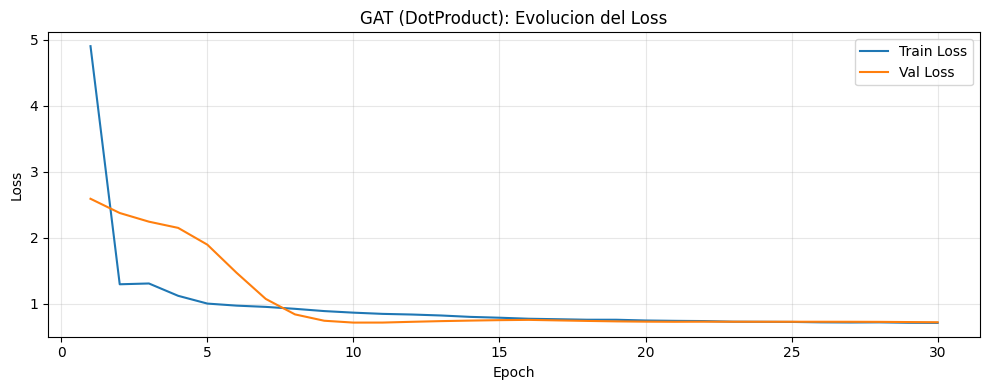

AUC: 0.6371575182618024


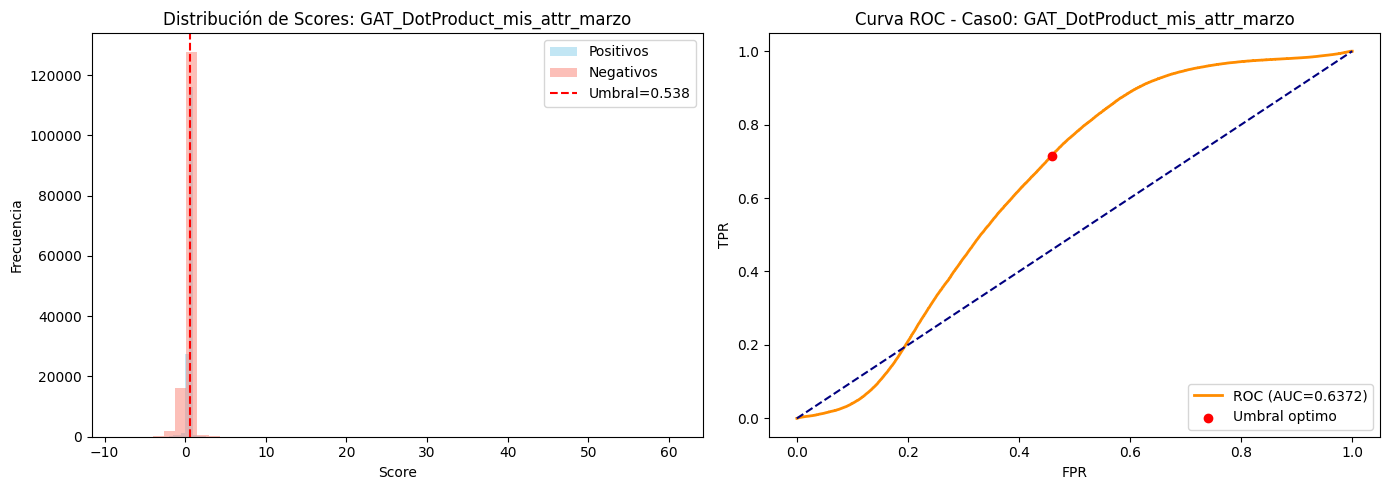

Accuracy: 0.6286 (Threshold: 0.54)



In [13]:
attr = 'mis_attr_marzo'
decoder = 'DotProduct'
in_feats = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats = 64
out_feats = 32
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso0'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [DotProduct] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats, hidden_feats=hidden_feats,
        out_feats=out_feats, out_feats_mlp=out_feats_mlp)

    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    for e in range(NUM_EPOCHS):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeDotProduct(gnn.train_pos_g, h)
        neg_score = model.decodeDotProduct(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeDotProduct(gnn.test_pos_g, h_eval),
                model.decodeDotProduct(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (DotProduct): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeDotProduct(gnn.test_pos_g, best_h)
        neg_score = model.decodeDotProduct(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_DotProduct_' + attr, 'Caso0')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()


MLP


Training model: GCN [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6993  val=0.7129
  Epoch  10: train=0.3088  val=0.7609
  Epoch  20: train=0.1027  val=1.2349
  Early stopping epoch 25. Best val loss: 0.6790


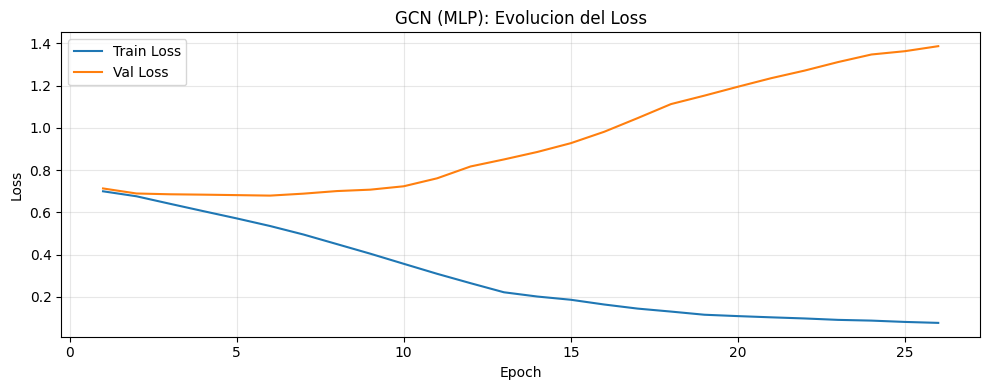

AUC: 0.08690712840758616


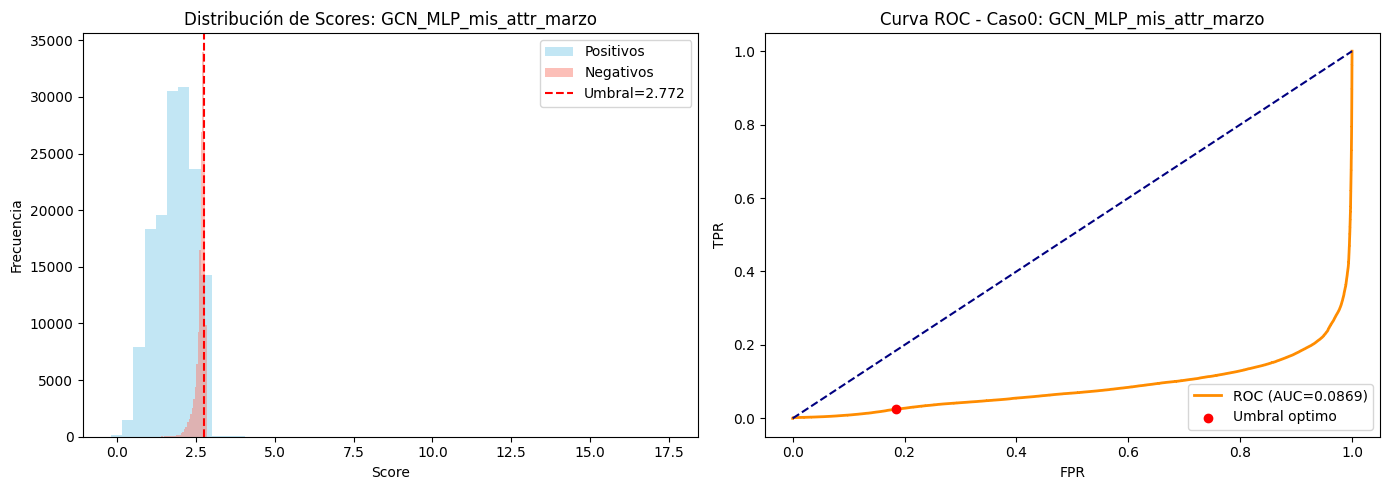

Accuracy: 0.4201 (Threshold: 2.77)


Training model: GraphSAGE [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6981  val=0.6874
  Epoch  10: train=0.3580  val=0.8132
  Epoch  20: train=0.1437  val=1.0610
  Early stopping epoch 23. Best val loss: 0.6765


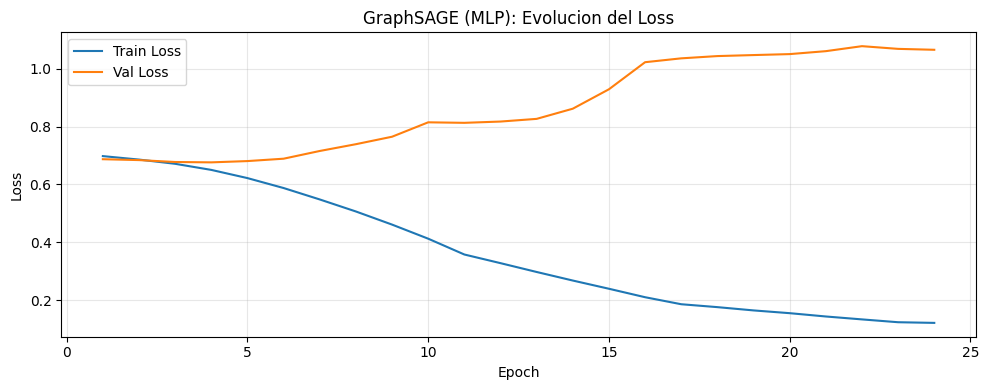

AUC: 0.5128556065042313


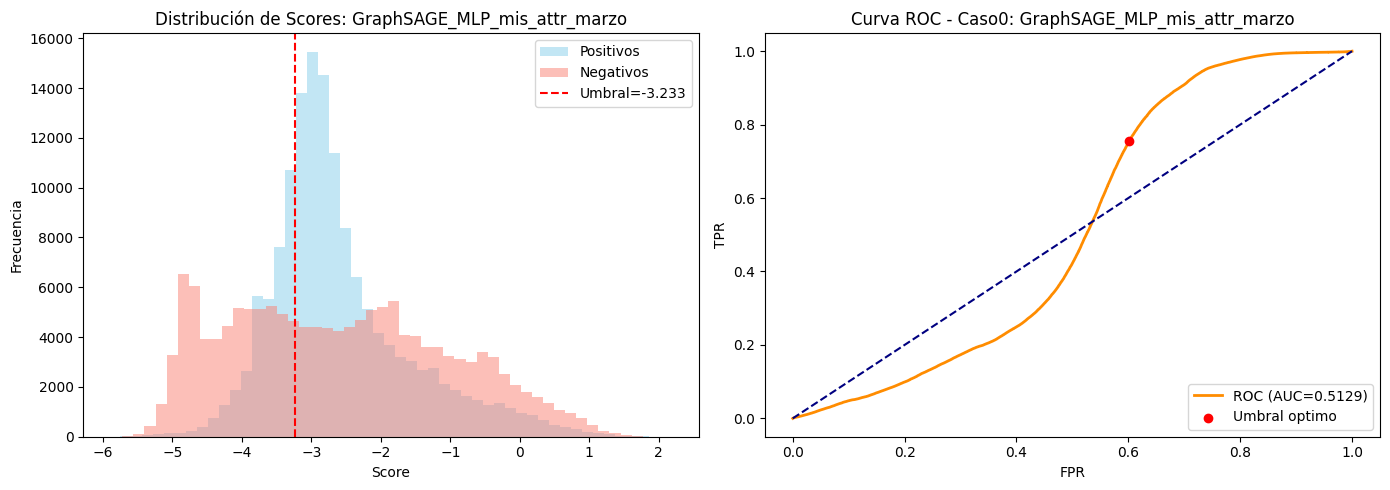

Accuracy: 0.5766 (Threshold: -3.23)


Training model: GAT [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6961  val=0.6967
  Epoch  10: train=0.3328  val=0.5993
  Epoch  20: train=0.0662  val=0.8741
  Epoch  30: train=0.0380  val=1.1771
  Early stopping epoch 30. Best val loss: 0.5993


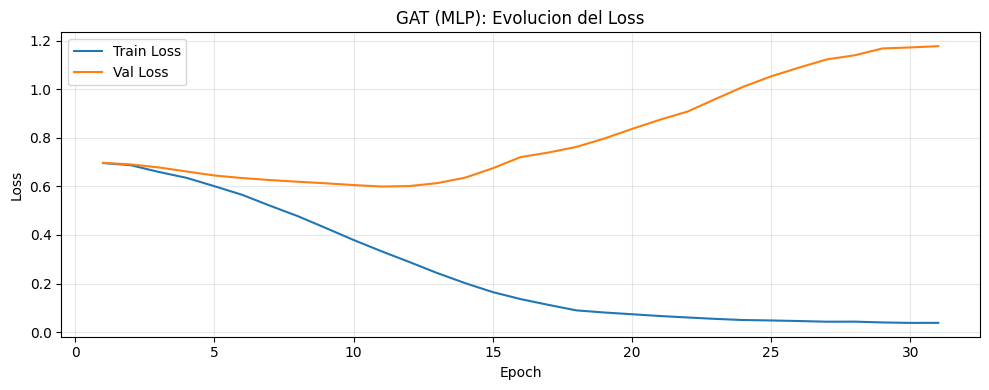

AUC: 0.6898055253292221


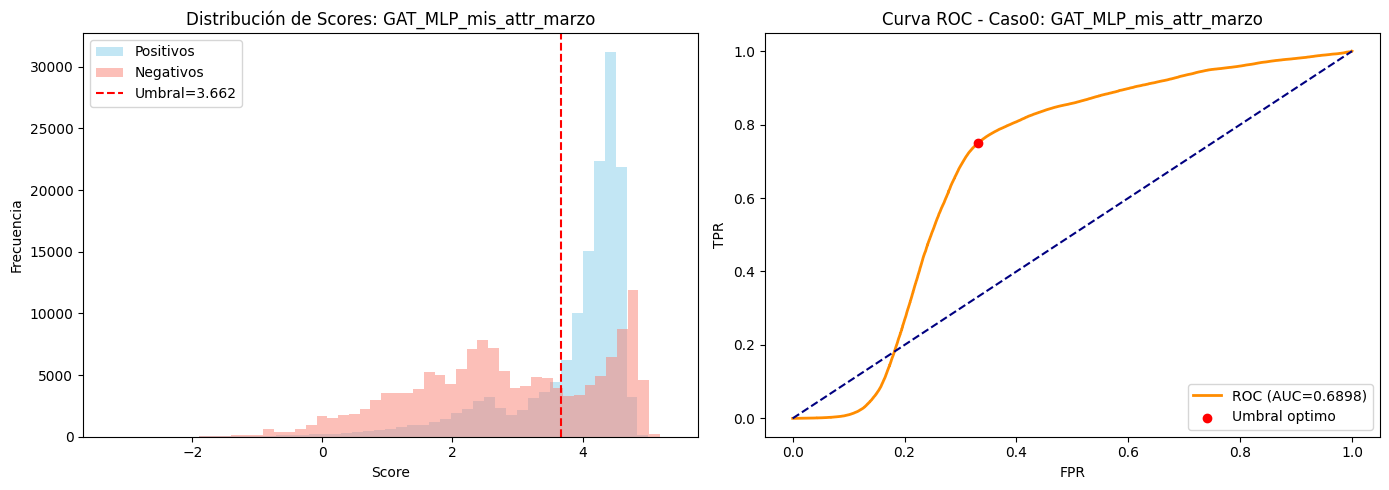

Accuracy: 0.7093 (Threshold: 3.66)



In [14]:
# attr definido en celda anterior
decoder = 'MLP'
in_feats = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats = 64
out_feats = 32
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso0'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [MLP] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats, hidden_feats=hidden_feats,
        out_feats=out_feats, out_feats_mlp=out_feats_mlp)

    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    for e in range(NUM_EPOCHS):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeMLP(gnn.train_pos_g, h)
        neg_score = model.decodeMLP(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeMLP(gnn.test_pos_g, h_eval),
                model.decodeMLP(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (MLP): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeMLP(gnn.test_pos_g, best_h)
        neg_score = model.decodeMLP(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_MLP_' + attr, 'Caso0')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()


### Caso 1: Predicción de enlaces utilizando grafo con atributos de centralidad

In [15]:
models = {
    'GCN': GCN,
    'GraphSAGE': GraphSAGE,
    'GAT': GAT,
}

# CASO 1: Grafo con atributos de grado de entrada y salida:
# ---------------------------------------
attr = 'grado_attr_febrero' 


In [17]:
# 1. Cargar datos con el nuevo formato (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))


gnn.split_edges_link_prediction(0.8)


g0 = gnn.dgl_graph
print("\n[Resumen grafo cargado]")
print(f"- Nodos: {g0.num_nodes():,}")
print(f"- Aristas: {g0.num_edges():,}")
print(f"- Dimensión de features: {g0.ndata['feat'].shape[1]}")
print(f"- Edges data keys: {list(g0.edata.keys())}")

Grafo cargado: 79504 nodos, 734381 aristas
Dimensión de entrada (in_feats): 72
[split_basic] +pos train=587504  +pos test=146877
[split_basic] -neg train=587504 -neg test=146877

[Resumen grafo cargado]
- Nodos: 79,504
- Aristas: 734,381
- Dimensión de features: 72
- Edges data keys: ['label']


DotProduct


Training model: GCN [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=10.3813  val=0.7696
  Epoch  10: train=1.7946  val=0.9337
  Epoch  20: train=1.3544  val=1.3191
  Early stopping epoch 24. Best val loss: 0.6673


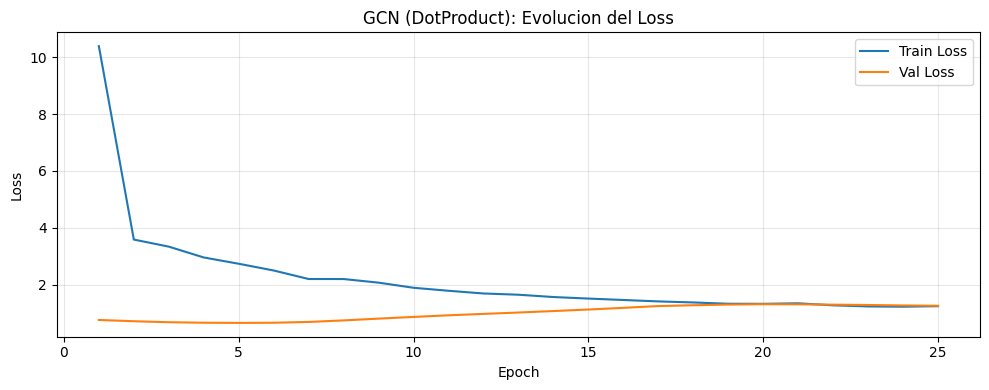

AUC: 0.9299114764070112


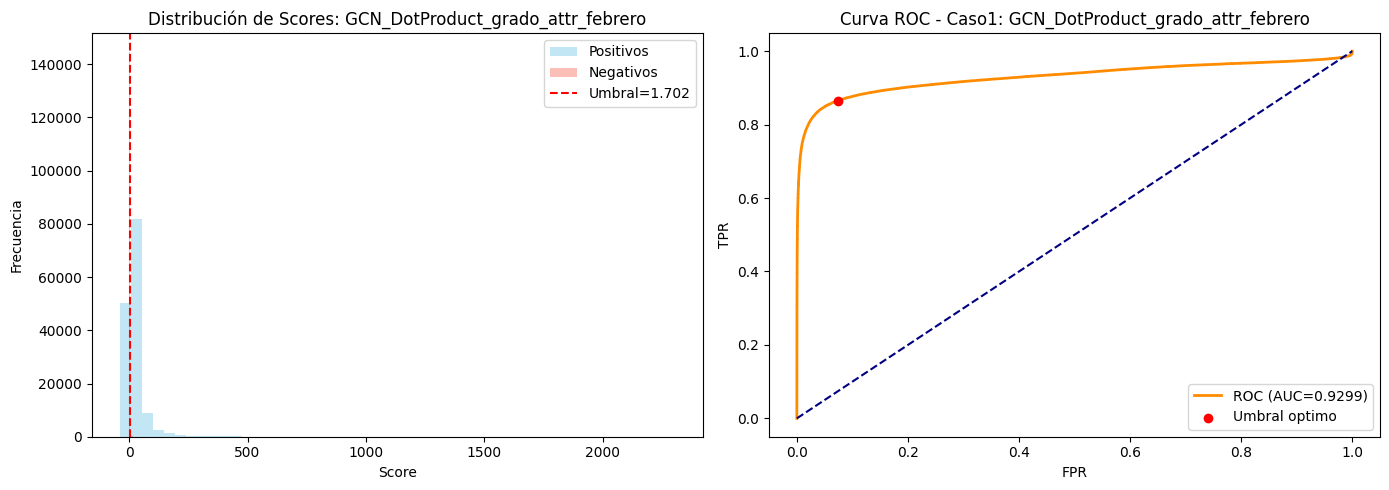

Accuracy: 0.8960 (Threshold: 1.70)


Training model: GraphSAGE [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=2.0885  val=9.1884
  Epoch  10: train=0.9763  val=0.8026
  Epoch  20: train=0.7739  val=0.7379
  Epoch  30: train=0.6860  val=0.6435
  Epoch  40: train=0.6300  val=0.5976
  Epoch  50: train=0.5952  val=0.5756
  Epoch  60: train=0.5740  val=0.5595
  Epoch  70: train=0.5553  val=0.5491
  Epoch  80: train=0.5371  val=0.5428
  Epoch  90: train=0.5268  val=0.5424


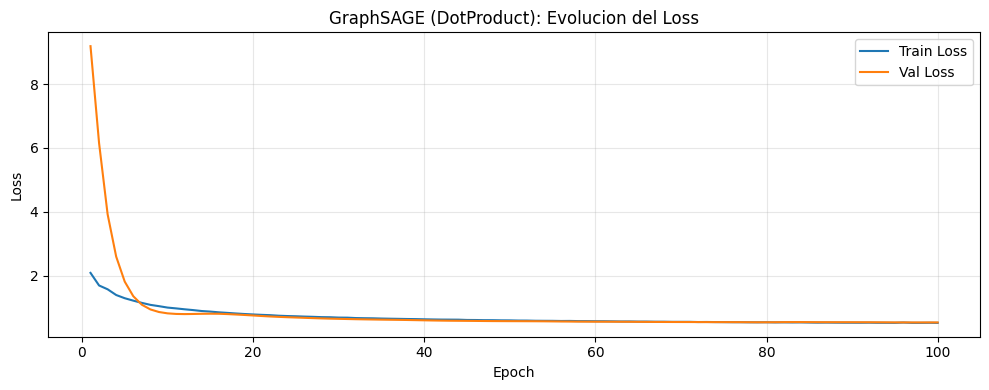

AUC: 0.8823759532025505


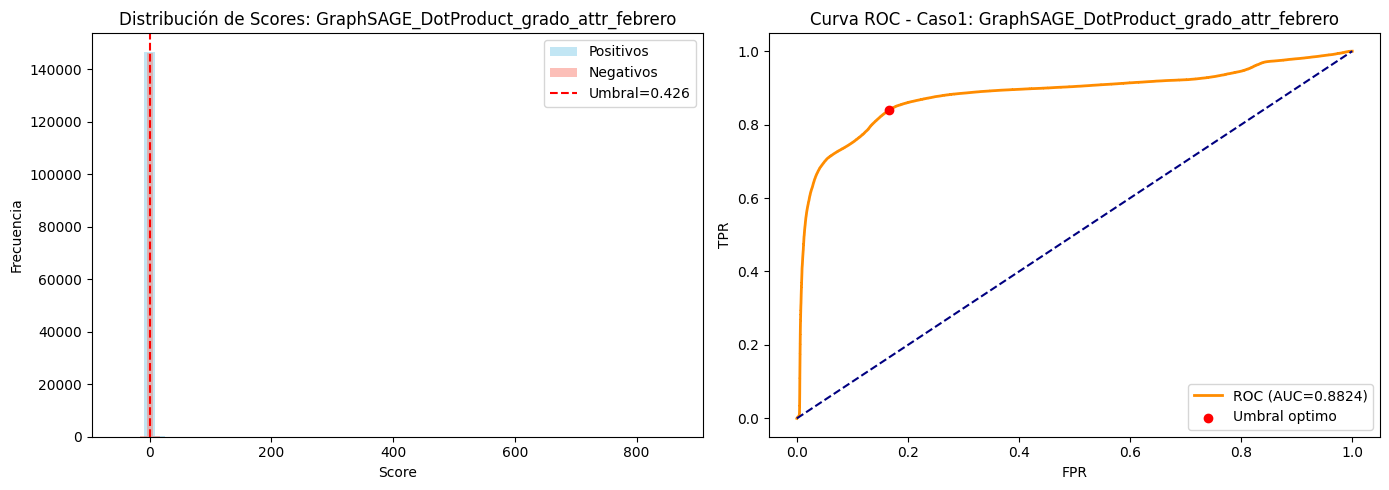

Accuracy: 0.8368 (Threshold: 0.43)


Training model: GAT [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=4.0268  val=4.6852
  Epoch  10: train=0.8343  val=1.0423
  Epoch  20: train=0.7247  val=0.7594
  Epoch  30: train=0.6630  val=0.6974
  Epoch  40: train=0.6305  val=0.6739
  Epoch  50: train=0.6183  val=0.6421
  Epoch  60: train=0.6068  val=0.6221
  Epoch  70: train=0.5947  val=0.6043
  Epoch  80: train=0.5828  val=0.5985
  Epoch  90: train=0.5759  val=0.5885


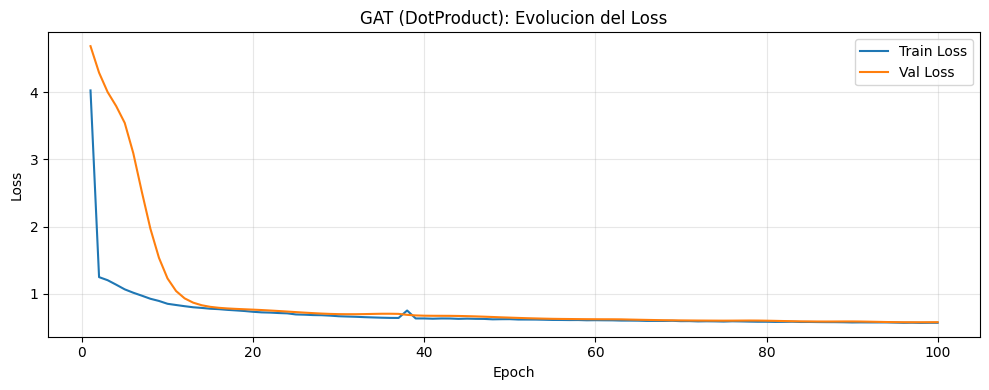

AUC: 0.8670023235061538


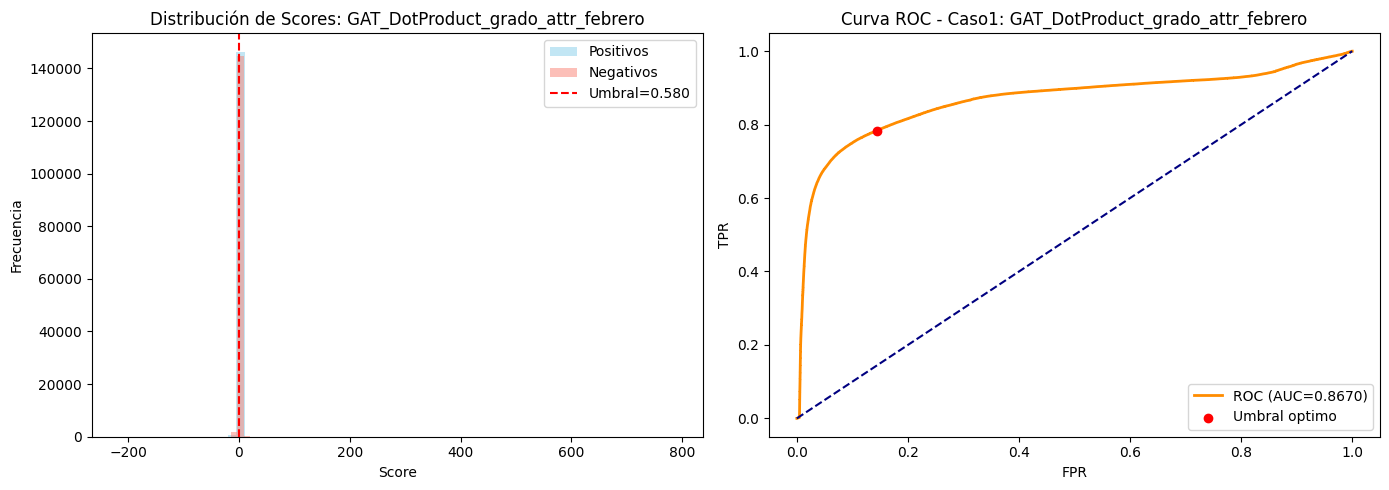

Accuracy: 0.8200 (Threshold: 0.58)



In [18]:
# attr = 'grado_attr_febrero' (definido arriba)
decoder = 'DotProduct'
in_feats = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats = 64
out_feats = 32
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso1'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [DotProduct] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats, hidden_feats=hidden_feats,
        out_feats=out_feats, out_feats_mlp=out_feats_mlp)

    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    for e in range(NUM_EPOCHS):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeDotProduct(gnn.train_pos_g, h)
        neg_score = model.decodeDotProduct(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeDotProduct(gnn.test_pos_g, h_eval),
                model.decodeDotProduct(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (DotProduct): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeDotProduct(gnn.test_pos_g, best_h)
        neg_score = model.decodeDotProduct(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_DotProduct_' + attr, 'Caso1')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()


MLP



Training model: GCN [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.7028  val=0.6942
  Epoch  10: train=0.3361  val=0.7734
  Epoch  20: train=0.1650  val=1.1121
  Early stopping epoch 22. Best val loss: 0.6761


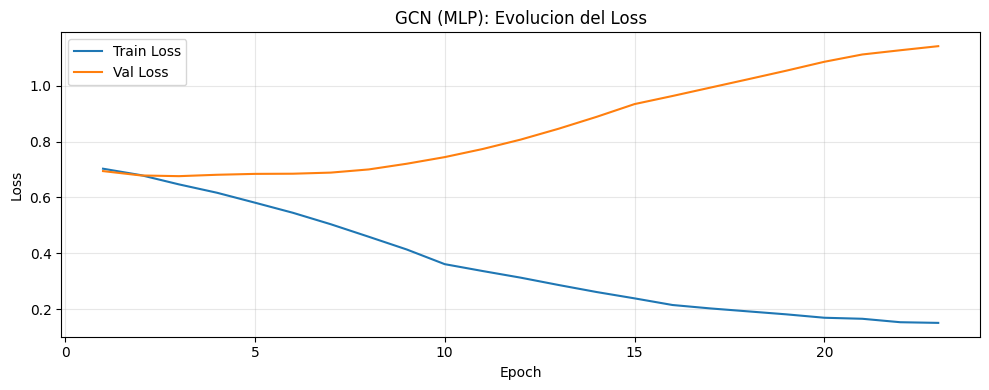

AUC: 0.047406198887305274


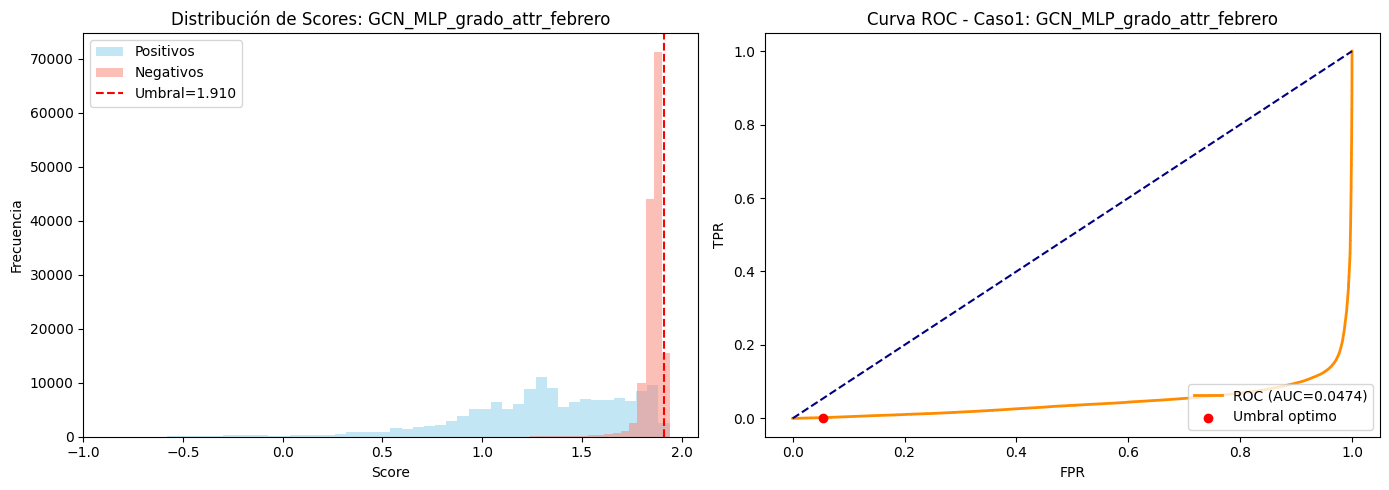

Accuracy: 0.4740 (Threshold: 1.91)


Training model: GraphSAGE [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.7036  val=0.7029
  Epoch  10: train=0.4828  val=0.7072
  Epoch  20: train=0.1560  val=1.0183
  Early stopping epoch 27. Best val loss: 0.6635


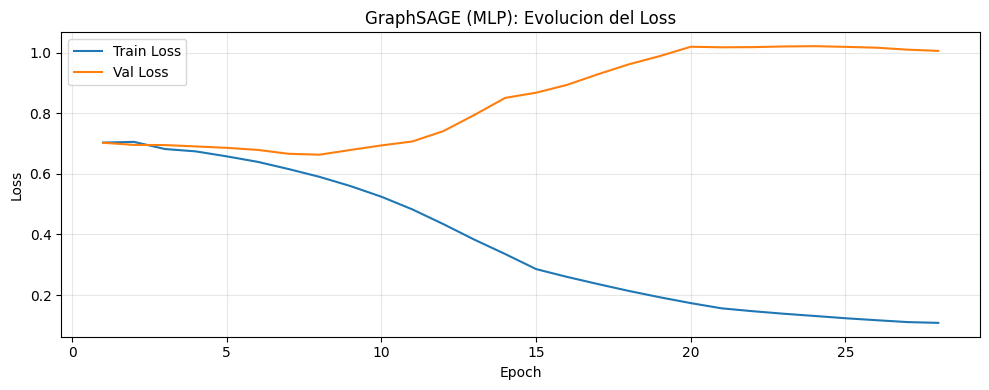

AUC: 0.6741495924778564


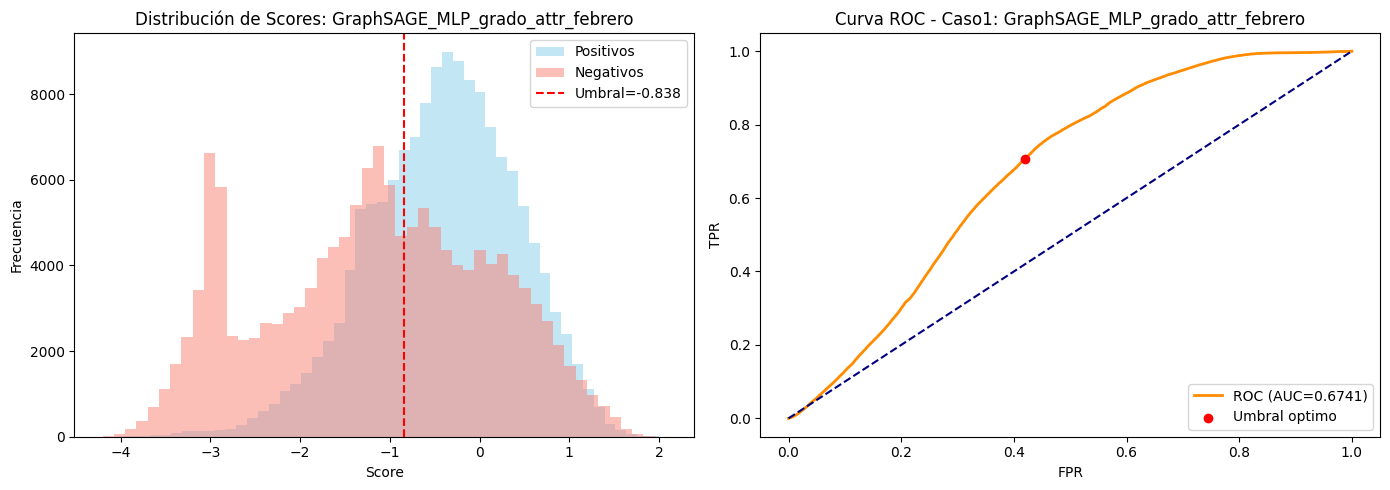

Accuracy: 0.6438 (Threshold: -0.84)


Training model: GAT [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6999  val=0.6914
  Epoch  10: train=0.3818  val=0.6335
  Epoch  20: train=0.0666  val=0.7466
  Epoch  30: train=0.0329  val=0.9204
  Early stopping epoch 33. Best val loss: 0.6248


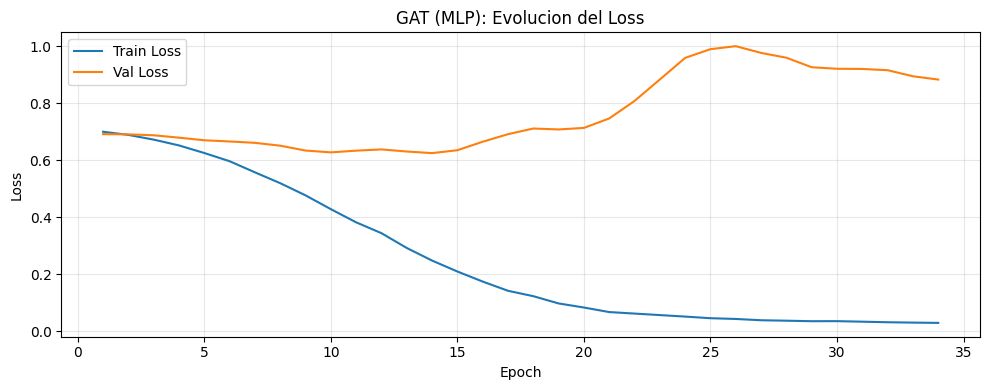

AUC: 0.7686593079201416


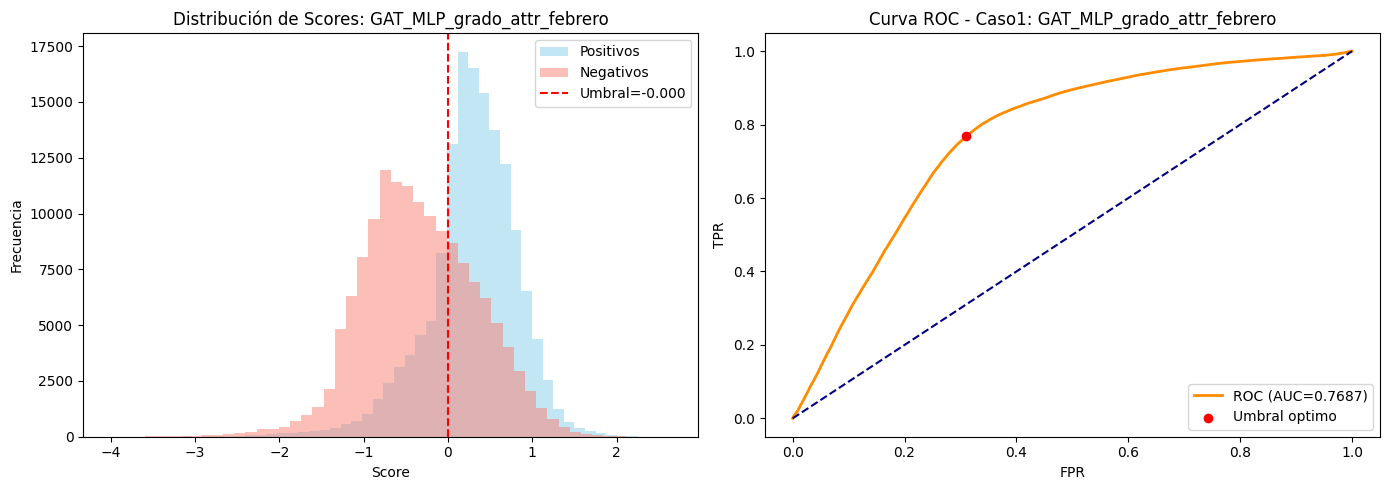

Accuracy: 0.7289 (Threshold: -0.00)



In [19]:
# attr = 'grado_attr_febrero' (definido arriba)
decoder = 'MLP'
in_feats = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats = 64
out_feats = 32
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso1'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [MLP] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats, hidden_feats=hidden_feats,
        out_feats=out_feats, out_feats_mlp=out_feats_mlp)

    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    for e in range(NUM_EPOCHS):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeMLP(gnn.train_pos_g, h)
        neg_score = model.decodeMLP(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeMLP(gnn.test_pos_g, h_eval),
                model.decodeMLP(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (MLP): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeMLP(gnn.test_pos_g, best_h)
        neg_score = model.decodeMLP(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_MLP_' + attr, 'Caso1')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()


### Caso 2: Predicción de enlaces utilizando grafo con atributos provenientes de estudios pre

In [20]:
models = {
    'GCN': GCN,
    'GraphSAGE': GraphSAGE,
    'GAT': GAT,
}

# CASO 2: Grafo 2022 con atributos de nodos del paper
# ---------------------------------------
attr = '2022_attr'
INTERNETGRAPH_FILE = '/media/vale/KINGSTON/TESIS/InternetGNNData2022/caida/caida.bin'

gnn = GNN(debug=True)
graphs, _ = dgl.load_graphs(INTERNETGRAPH_FILE)
gnn.dgl_graph = graphs[0]
print(f'Grafo 2022: {gnn.dgl_graph.num_nodes():,} nodos, {gnn.dgl_graph.num_edges():,} aristas')
print(f'Dimensión de features: {gnn.dgl_graph.ndata["feat"].shape[1]}')

gnn.split_edges_link_prediction(0.8)


Grafo 2022: 46,235 nodos, 433,979 aristas
Dimensión de features: 72
[split_basic] +pos train=347183  +pos test=86796
[split_basic] -neg train=347183 -neg test=86796


DotProduct


Training model: GCN [DotProduct] ----------------------------------------
  Epoch   0: train=4.7755  val=0.6204


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch  10: train=1.1351  val=0.6458
  Epoch  20: train=0.9511  val=0.6390
  Early stopping epoch 22. Best val loss: 0.5985


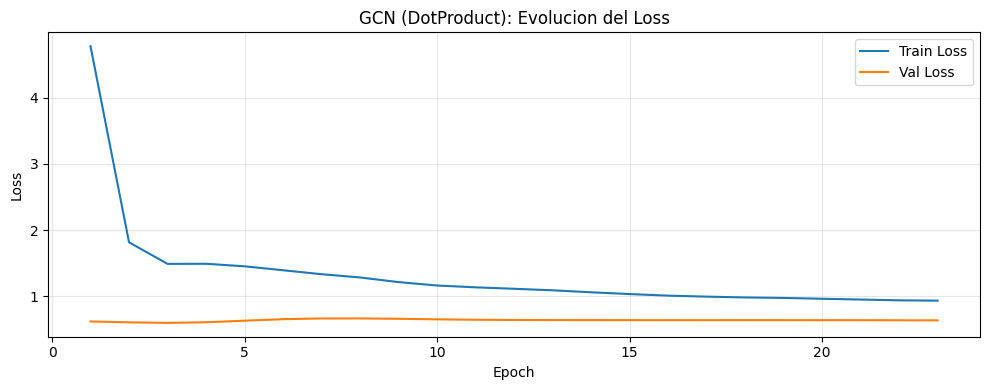

AUC: 0.8688245959643235


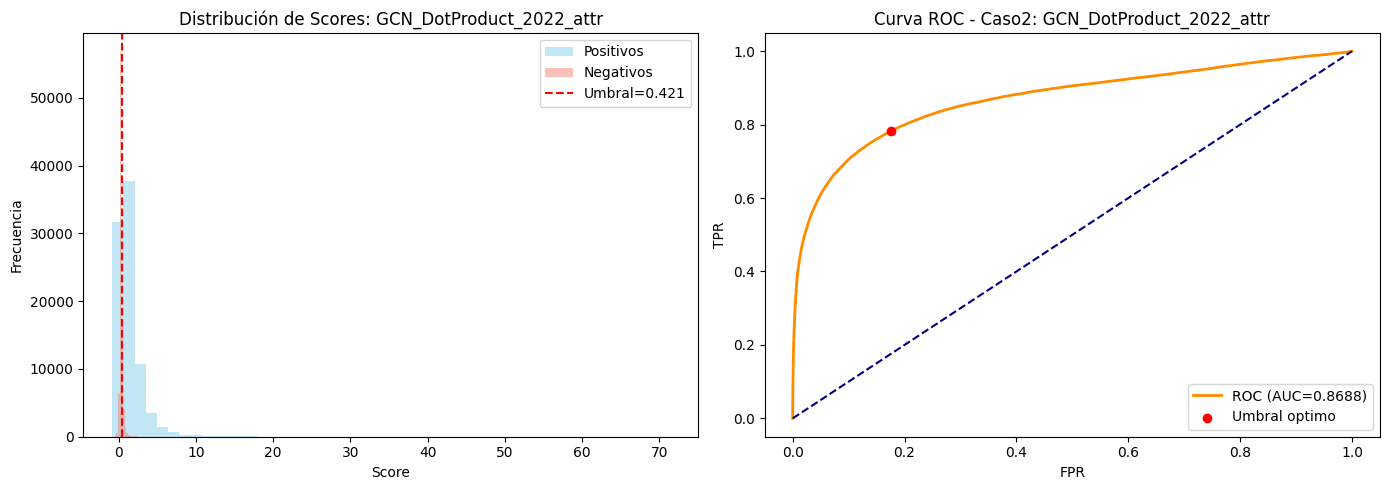

Accuracy: 0.8035 (Threshold: 0.42)


Training model: GraphSAGE [DotProduct] ----------------------------------------
  Epoch   0: train=2.1608  val=12.7540


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch  10: train=1.0340  val=1.4240
  Epoch  20: train=0.7868  val=0.8613
  Epoch  30: train=0.6626  val=0.6851
  Epoch  40: train=0.5894  val=0.5998
  Epoch  50: train=0.5477  val=0.5539
  Epoch  60: train=0.5100  val=0.5225
  Epoch  70: train=0.4851  val=0.5034
  Epoch  80: train=0.4636  val=0.4931
  Epoch  90: train=0.4501  val=0.4916


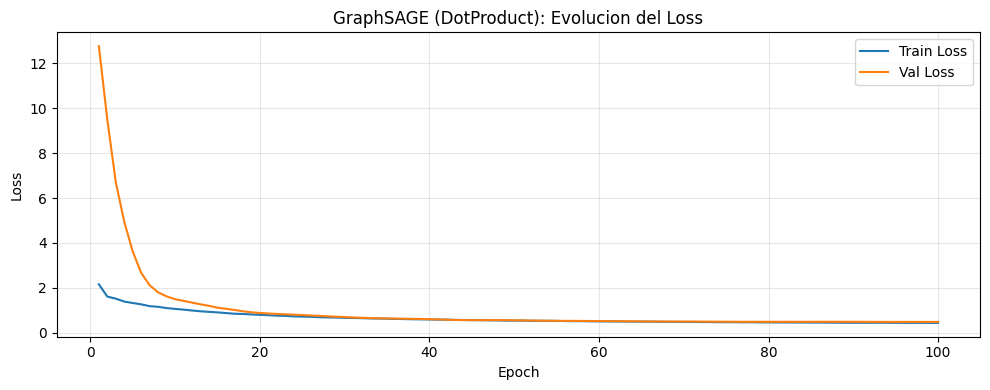

AUC: 0.9018095095317467


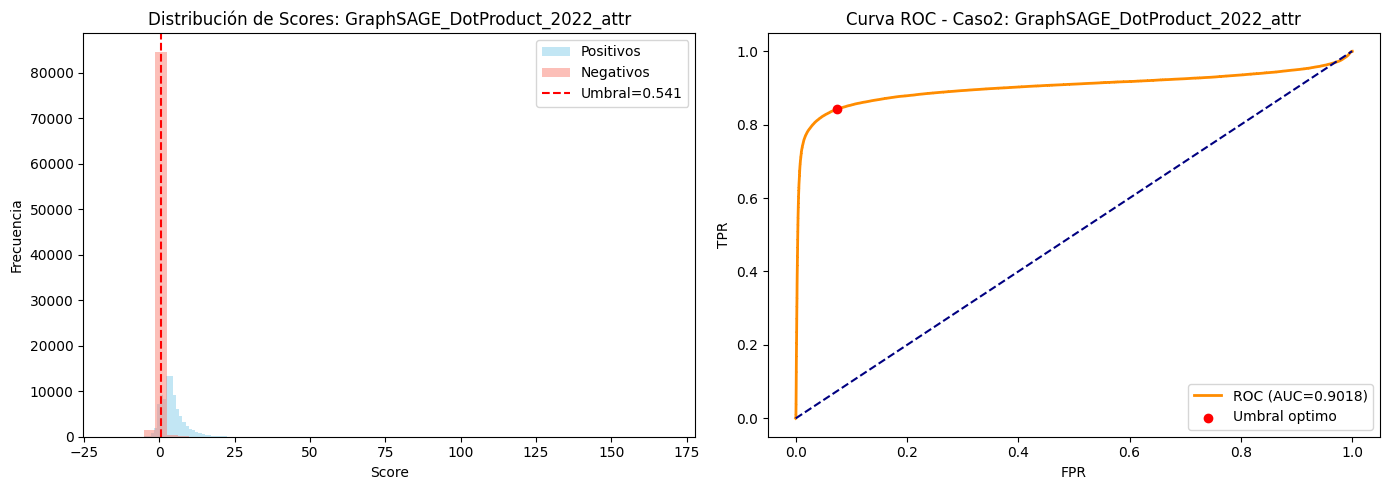

Accuracy: 0.8838 (Threshold: 0.54)


Training model: GAT [DotProduct] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=1.7109  val=1.8231
  Epoch  10: train=0.8777  val=1.0756
  Epoch  20: train=0.7274  val=0.9242
  Epoch  30: train=0.6775  val=0.6786
  Epoch  40: train=0.6426  val=0.6189
  Epoch  50: train=0.6124  val=0.6038
  Epoch  60: train=0.5806  val=0.5928
  Epoch  70: train=0.5633  val=0.5813
  Epoch  80: train=0.5387  val=0.5743
  Epoch  90: train=0.5219  val=0.5691


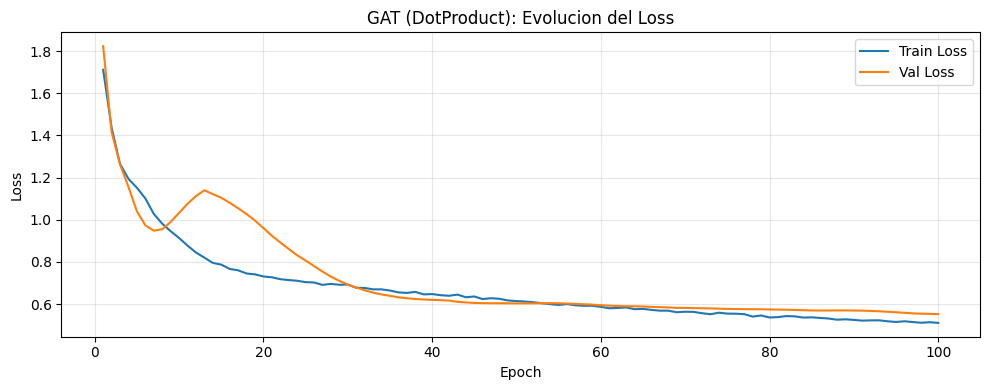

AUC: 0.8922920161554908


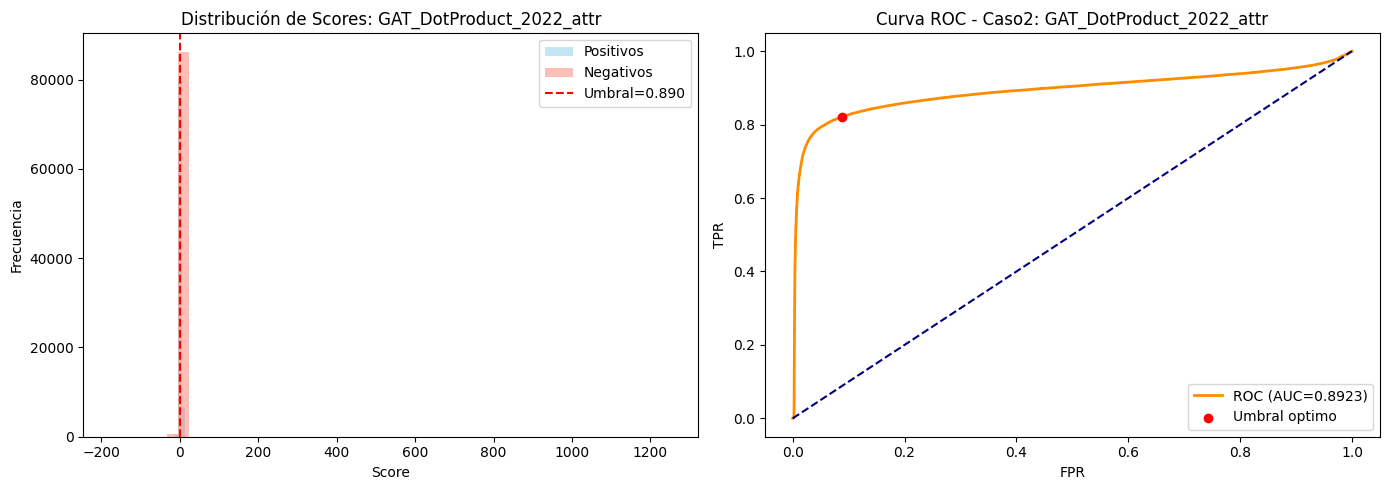

Accuracy: 0.8667 (Threshold: 0.89)



In [21]:
# attr = '2022_attr' (definido arriba)
decoder = 'DotProduct'
in_feats = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats = 64
out_feats = 32
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso2'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [DotProduct] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats, hidden_feats=hidden_feats,
        out_feats=out_feats, out_feats_mlp=out_feats_mlp)

    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    for e in range(NUM_EPOCHS):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeDotProduct(gnn.train_pos_g, h)
        neg_score = model.decodeDotProduct(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeDotProduct(gnn.test_pos_g, h_eval),
                model.decodeDotProduct(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (DotProduct): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeDotProduct(gnn.test_pos_g, best_h)
        neg_score = model.decodeDotProduct(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_DotProduct_' + attr, 'Caso2')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()


MLP


Training model: GCN [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6988  val=0.6930
  Epoch  10: train=0.2806  val=0.6929
  Epoch  20: train=0.0620  val=1.4429
  Early stopping epoch 27. Best val loss: 0.6546


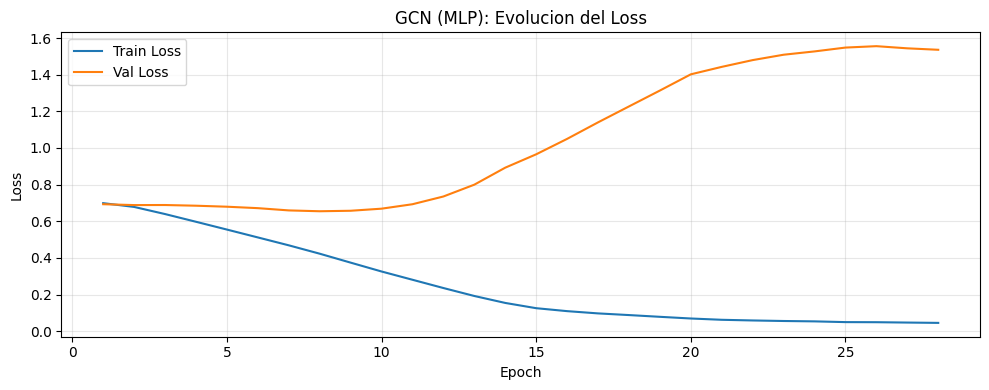

AUC: 0.41557301708651384


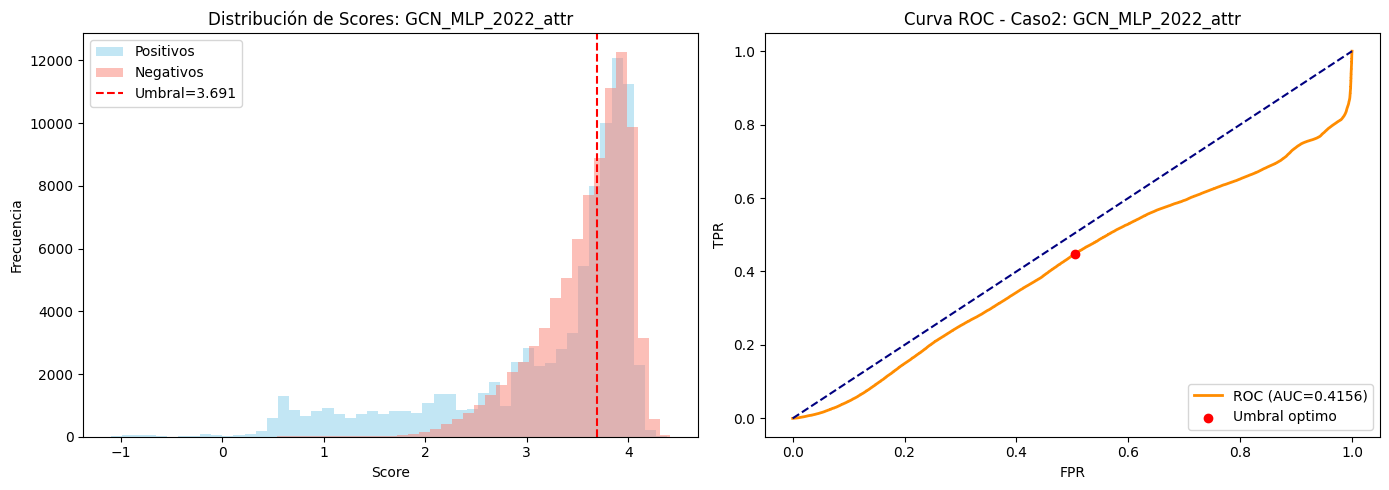

Accuracy: 0.4720 (Threshold: 3.69)


Training model: GraphSAGE [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.7046  val=0.6878
  Epoch  10: train=0.4520  val=0.5806
  Epoch  20: train=0.1402  val=0.7119
  Early stopping epoch 29. Best val loss: 0.5750


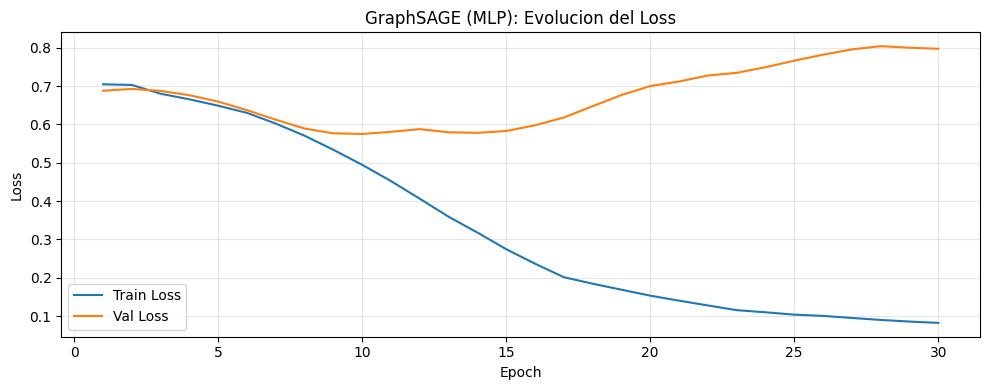

AUC: 0.35660302969352853


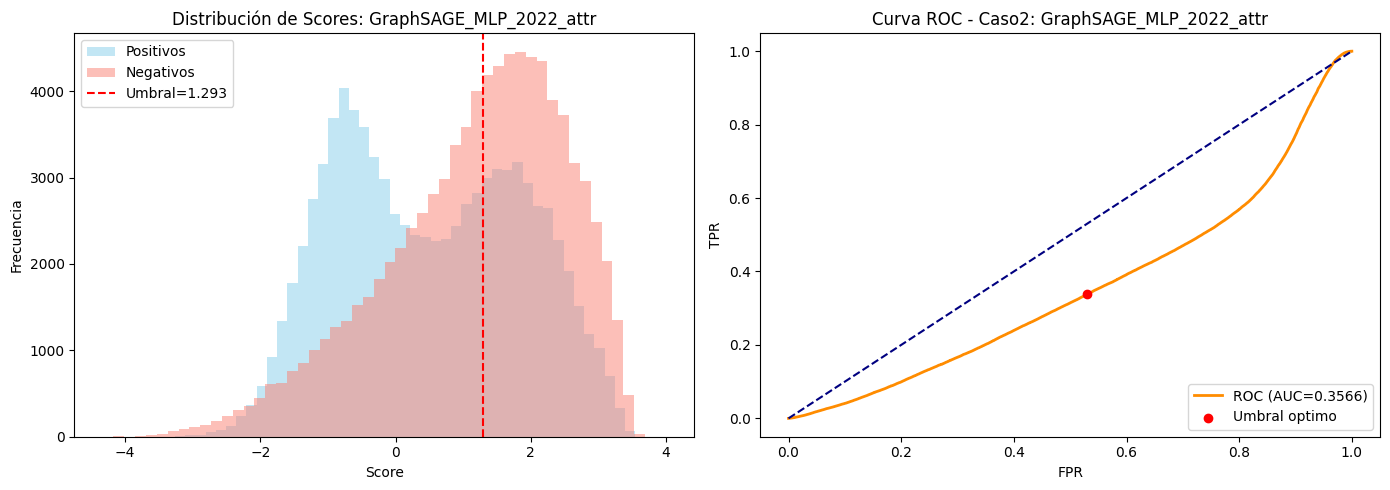

Accuracy: 0.4041 (Threshold: 1.29)


Training model: GAT [MLP] ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.6992  val=0.6950
  Epoch  10: train=0.4047  val=0.6809
  Epoch  20: train=0.1013  val=0.8963
  Early stopping epoch 29. Best val loss: 0.6687


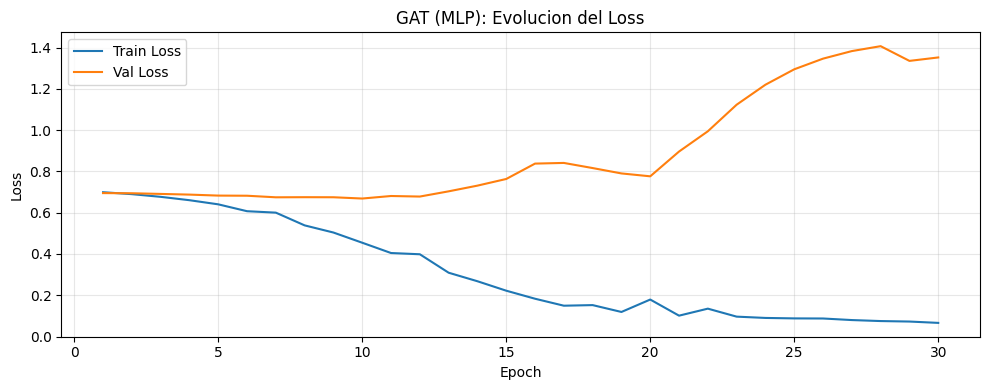

AUC: 0.5442136525718488


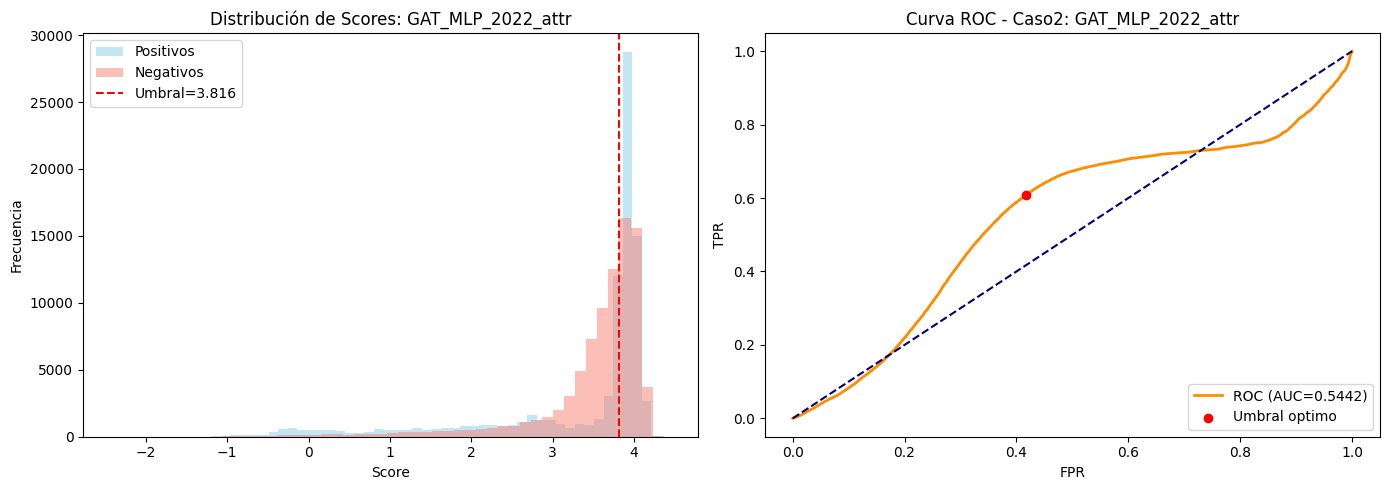

Accuracy: 0.5958 (Threshold: 3.82)



In [22]:
# attr = '2022_attr' (definido arriba)
decoder = 'MLP'
in_feats = gnn.dgl_graph.ndata['feat'].shape[1]
hidden_feats = 64
out_feats = 32
out_feats_mlp = 1

save_dir = data_path + 'results/EnfoquePorPartes/Caso2'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} [MLP] ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats, hidden_feats=hidden_feats,
        out_feats=out_feats, out_feats_mlp=out_feats_mlp)

    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_h = None
    patience_counter = 0

    for e in range(NUM_EPOCHS):
        model.train()
        h = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
        pos_score = model.decodeMLP(gnn.train_pos_g, h)
        neg_score = model.decodeMLP(gnn.train_neg_g, h)
        loss = compute_loss(pos_score, neg_score)
        train_losses.append(loss.item())
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            h_eval = model.encode(gnn.train_g, gnn.train_g.ndata['feat'])
            val_loss = compute_loss(
                model.decodeMLP(gnn.test_pos_g, h_eval),
                model.decodeMLP(gnn.test_neg_g, h_eval))
        val_losses.append(val_loss.item())
        scheduler.step(val_loss.item())

        if e % 10 == 0:
            print(f'  Epoch {e:3d}: train={loss.item():.4f}  val={val_loss.item():.4f}')

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_h = h_eval.clone()
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping epoch {e}. Best val loss: {best_val_loss:.4f}')
            break

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name} (MLP): Evolucion del Loss',
                        val_losses=val_losses)

    with torch.no_grad():
        pos_score = model.decodeMLP(gnn.test_pos_g, best_h)
        neg_score = model.decodeMLP(gnn.test_neg_g, best_h)
        print('AUC:', compute_auc(pos_score, neg_score))
        threshold = plot_roc_with_distributions(
            pos_score, neg_score, model_name + '_MLP_' + attr, 'Caso2')
        compute_accuracy(pos_score, neg_score, threshold=threshold)

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{decoder}_{model_name}_{attr}.pth')
    torch.save(best_h,
               f'{save_dir}/embeddings_ribs_{decoder}_{model_name}_{attr}.pt')
    print()


### Caso 3: Predicción del grado de los nodos utilizando grafo con atributos extraídos de Peering

In [26]:
models = {
    'GCN': GCN,
    'GraphSAGE': GraphSAGE,
    'GAT': GAT,
}

# CASO 3: Grafo con atributos de nodos extraídos de PeeringDB
# ---------------------------------------
attr = 'out_degree'

# 1. Cargar datos con el nuevo formato (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))


gnn.split_graph_nodes(train_size=0.8)


g0 = gnn.dgl_graph

Grafo cargado: 79504 nodos, 734381 aristas
Dimensión de entrada (in_feats): 72
Train nodes: 63603, Test nodes: 15901


In [27]:
degrees = gnn.dgl_graph.out_degrees(gnn.dgl_graph.nodes()).float().unsqueeze(1)

# Transformación logarítmica
deg_log = torch.log1p(degrees)  # log(1 + x)

# Min-max normalization después del log
min_val = deg_log.min()
max_val = deg_log.max()
deg_log_norm = (deg_log - min_val) / (max_val - min_val + 1e-8)

gnn.dgl_graph.ndata['out_degree'] = deg_log_norm



Split => Train: 50883 | Val: 12720 | Test: 15901

Training model: GCN ----------------------------------------
  Epoch   0: train=0.084460  val=0.085124


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch  10: train=0.085500  val=0.084976
  Epoch  20: train=0.054634  val=0.054885
  Epoch  30: train=0.057459  val=0.057743
  Epoch  40: train=0.047319  val=0.047802
  Epoch  50: train=0.040620  val=0.041178
  Epoch  60: train=0.039756  val=0.040434
  Epoch  70: train=0.039482  val=0.040255
  Epoch  80: train=0.039110  val=0.039887
  Epoch  90: train=0.039117  val=0.039924
  Epoch  99: train=0.038483  val=0.039256


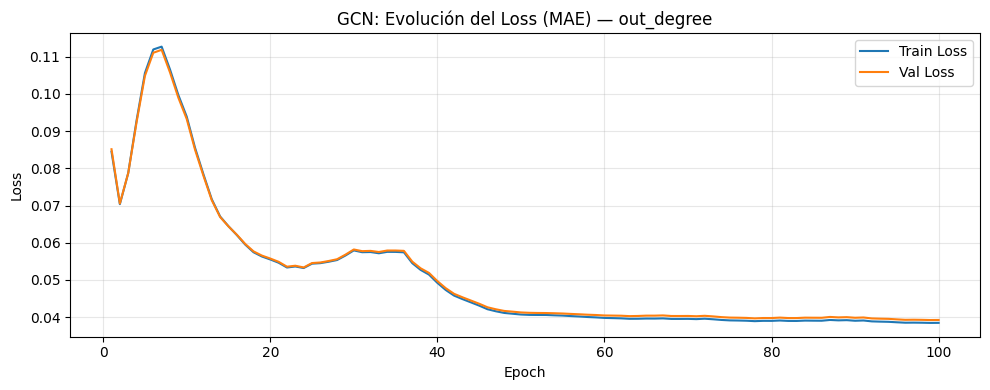

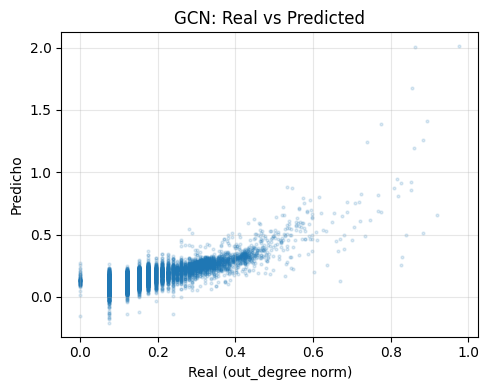


  [Métricas GCN]
  Best Val MAE : 0.039239
  Test MAE     : 0.038760
  Test R²      : 0.664263
  Guardado: embeddings_ribs_GCN_out_degree.pt


Training model: GraphSAGE ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.390877  val=0.391918
  Epoch  10: train=0.115299  val=0.115717
  Epoch  20: train=0.089598  val=0.090001
  Epoch  30: train=0.073025  val=0.073165
  Epoch  40: train=0.068071  val=0.067942
  Epoch  50: train=0.062700  val=0.062523
  Epoch  60: train=0.057735  val=0.057689
  Epoch  70: train=0.052950  val=0.052936
  Epoch  80: train=0.050221  val=0.050269
  Epoch  90: train=0.048982  val=0.049018
  Epoch  99: train=0.048553  val=0.048574


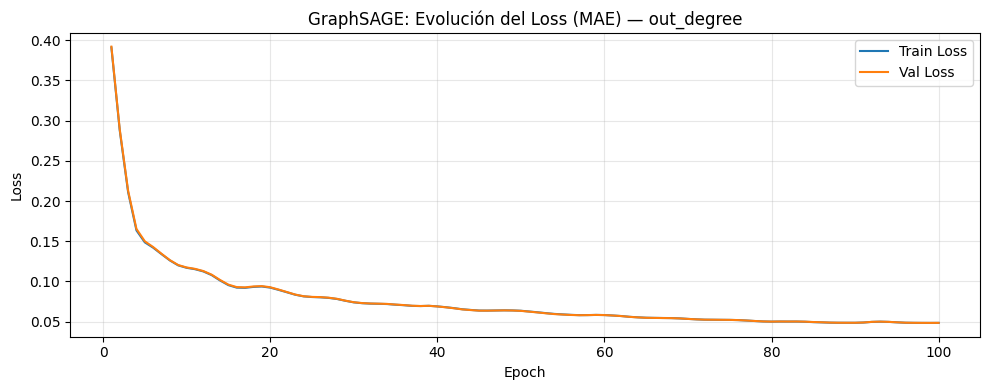

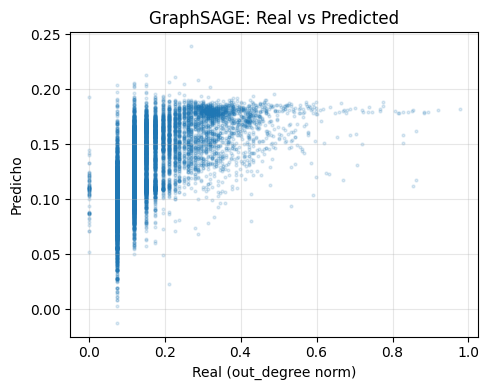


  [Métricas GraphSAGE]
  Best Val MAE : 0.048536
  Test MAE     : 0.049424
  Test R²      : 0.253648
  Guardado: embeddings_ribs_GraphSAGE_out_degree.pt


Training model: GAT ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.568268  val=0.568154
  Epoch  10: train=0.107815  val=0.108227
  Epoch  20: train=0.078346  val=0.078553
  Epoch  30: train=0.088333  val=0.089361
  Early stopping epoch 34. Best val MAE: 0.075937


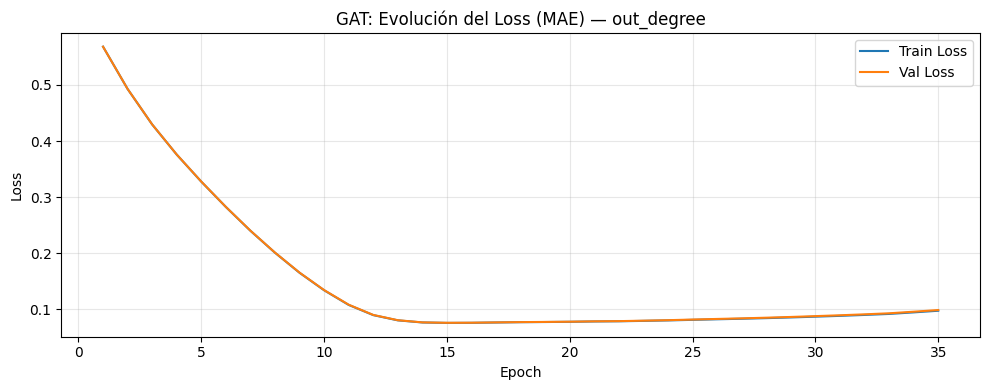

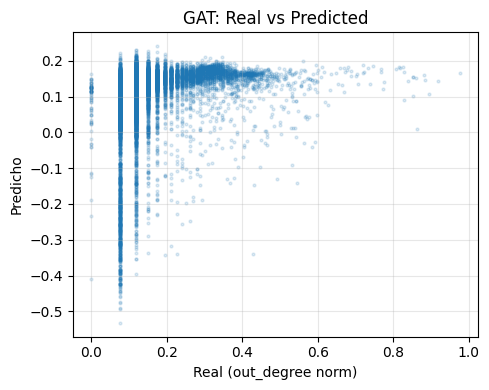


  [Métricas GAT]
  Best Val MAE : 0.075937
  Test MAE     : 0.075345
  Test R²      : -0.606574
  Guardado: embeddings_ribs_GAT_out_degree.pt



In [28]:
attr = 'out_degree'
features = gnn.dgl_graph.ndata['feat']
labels   = gnn.dgl_graph.ndata['out_degree']

# Split: 64% train / 16% val / 20% test
train_mask_orig     = gnn.dgl_graph.ndata['train_mask']
test_mask           = gnn.dgl_graph.ndata['test_mask']
train_indices       = torch.where(train_mask_orig)[0]
g_seed              = torch.Generator().manual_seed(42)
perm                = torch.randperm(len(train_indices), generator=g_seed)
n_val               = int(0.2 * len(train_indices))
val_indices         = train_indices[perm[:n_val]]
train_indices_final = train_indices[perm[n_val:]]
val_mask  = torch.zeros(gnn.dgl_graph.num_nodes(), dtype=torch.bool)
val_mask[val_indices] = True
train_mask = torch.zeros(gnn.dgl_graph.num_nodes(), dtype=torch.bool)
train_mask[train_indices_final] = True
print(f'Split => Train: {train_mask.sum()} | Val: {val_mask.sum()} | Test: {test_mask.sum()}')

in_feats      = features.shape[1]
hidden_feats  = 64
out_feats     = 32
out_feats_mlp = 1
lr            = 1e-3
NUM_EPOCHS    = 100
PATIENCE      = 20
save_dir      = data_path + 'results/EnfoquePorPartes/Caso3'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats, hidden_feats=hidden_feats,
        out_feats=out_feats, out_feats_mlp=out_feats_mlp)

    loss_fn   = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss    = float('inf')
    best_state       = None
    patience_counter = 0

    for epoch in range(NUM_EPOCHS):
        model.train()
        pred = model(gnn.dgl_graph, features)
        loss = loss_fn(pred[train_mask], labels[train_mask])
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_eval = model(gnn.dgl_graph, features)
            train_mae = loss_fn(pred_eval[train_mask], labels[train_mask]).item()
            val_mae   = loss_fn(pred_eval[val_mask],   labels[val_mask]).item()
        train_losses.append(train_mae)
        val_losses.append(val_mae)
        scheduler.step(val_mae)

        if epoch % 10 == 0 or epoch == NUM_EPOCHS - 1:
            print(f'  Epoch {epoch:3d}: train={train_mae:.6f}  val={val_mae:.6f}')

        if val_mae < best_val_loss:
            best_val_loss    = val_mae
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping epoch {epoch}. Best val MAE: {best_val_loss:.6f}')
            break

    model.load_state_dict(best_state)
    model.eval()

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name}: Evolución del Loss (MAE) — out_degree',
                        val_losses=val_losses)

    with torch.no_grad():
        pred_final = model(gnn.dgl_graph, features)
        embeddings = model.encode(gnn.dgl_graph, features)

    pred_test   = pred_final[test_mask].cpu().numpy().flatten()
    labels_test = labels[test_mask].cpu().numpy().flatten()
    test_mae    = loss_fn(pred_final[test_mask], labels[test_mask]).item()
    r2          = r2_score(labels_test, pred_test)

    plt.figure(figsize=(5, 4))
    plt.scatter(labels_test, pred_test, alpha=0.15, s=4)
    plt.xlabel('Real (out_degree norm)')
    plt.ylabel('Predicho')
    plt.title(f'{model_name}: Real vs Predicted')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n  [Métricas {model_name}]')
    print(f'  Best Val MAE : {best_val_loss:.6f}')
    print(f'  Test MAE     : {test_mae:.6f}')
    print(f'  Test R\u00b2      : {r2:.6f}')

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{model_name}_{attr}.pth')
    torch.save(embeddings,
               f'{save_dir}/embeddings_ribs_{model_name}_{attr}.pt')
    print(f'  Guardado: embeddings_ribs_{model_name}_{attr}.pt')
    print()


ESTADÍSTICAS DEL GRAFO
Número de nodos (ASes): 79,504
Número de aristas: 734,381
Densidad del grafo: 0.000116

Grado de entrada promedio: 9.24
Grado de salida promedio: 9.24
Grado de entrada máximo: 9810
Grado de salida máximo: 9809


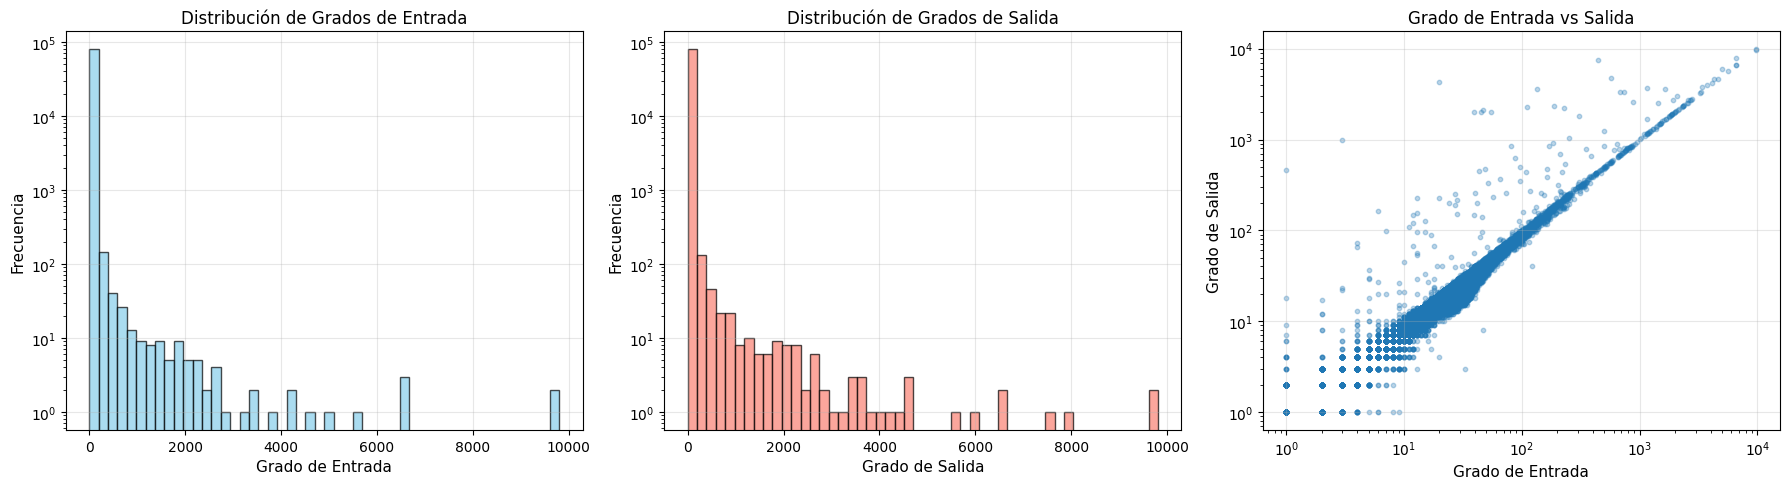

In [31]:
# Estadísticas del grafo
num_nodes = gnn.dgl_graph.num_nodes()
num_edges = gnn.dgl_graph.num_edges()
in_degrees = gnn.dgl_graph.in_degrees().numpy()
out_degrees = gnn.dgl_graph.out_degrees().numpy()

print("=" * 60)
print("ESTADÍSTICAS DEL GRAFO")
print("=" * 60)
print(f"Número de nodos (ASes): {num_nodes:,}")
print(f"Número de aristas: {num_edges:,}")
print(f"Densidad del grafo: {num_edges / (num_nodes * (num_nodes - 1)):.6f}")
print(f"\nGrado de entrada promedio: {in_degrees.mean():.2f}")
print(f"Grado de salida promedio: {out_degrees.mean():.2f}")
print(f"Grado de entrada máximo: {in_degrees.max()}")
print(f"Grado de salida máximo: {out_degrees.max()}")

# Visualizar distribución de grados
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de grados de entrada
axes[0].hist(in_degrees, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Grado de Entrada', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de Grados de Entrada', fontsize=12)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Histograma de grados de salida
axes[1].hist(out_degrees, bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Grado de Salida', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución de Grados de Salida', fontsize=12)
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Scatter plot: in-degree vs out-degree
axes[2].scatter(in_degrees, out_degrees, alpha=0.3, s=10)
axes[2].set_xlabel('Grado de Entrada', fontsize=11)
axes[2].set_ylabel('Grado de Salida', fontsize=11)
axes[2].set_title('Grado de Entrada vs Salida', fontsize=12)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Caso 4: Predicción del valor de PageRank utilizando grafo con atributos extraídos de PeeringDB

In [32]:
models = {
    'GCN': GCN,
    'GraphSAGE': GraphSAGE,
    'GAT': GAT,
}

attr = 'pagerank'

# Cargar grafo 
# ---------------------- 
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))


gnn.split_graph_nodes(train_size=0.8)


g4 = gnn.dgl_graph
g4


Grafo cargado: 79504 nodos, 734381 aristas
Dimensión de entrada (in_feats): 72
Train nodes: 63603, Test nodes: 15901


Graph(num_nodes=79504, num_edges=734381,
      ndata_schemes={'feat': Scheme(shape=(72,), dtype=torch.float32), 'train_mask': Scheme(shape=(), dtype=torch.bool), 'test_mask': Scheme(shape=(), dtype=torch.bool)}
      edata_schemes={'label': Scheme(shape=(), dtype=torch.int64)})

Calculo PageRank

PageRank raw   — min=0.000002  max=0.011451  mean=0.000012
PageRank norm  — min=0.0000  max=1.0000  mean=0.0009


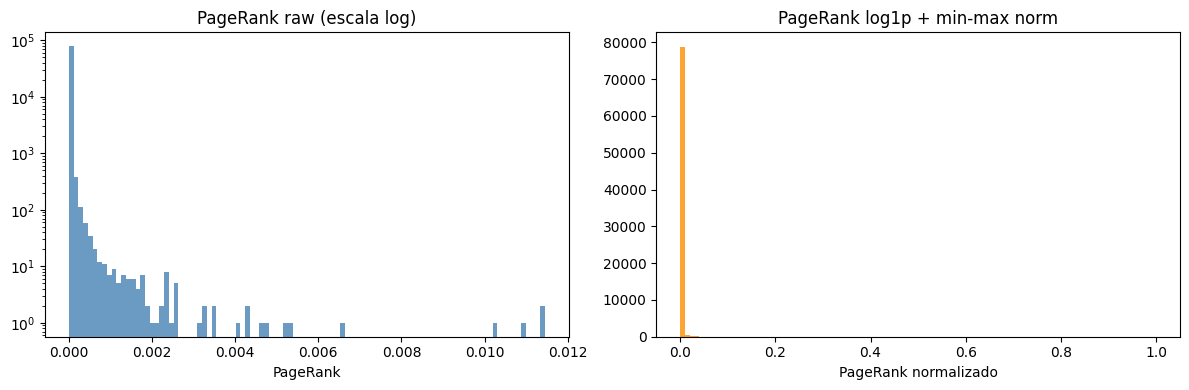

Graph(num_nodes=79504, num_edges=734381,
      ndata_schemes={'feat': Scheme(shape=(72,), dtype=torch.float32), 'train_mask': Scheme(shape=(), dtype=torch.bool), 'test_mask': Scheme(shape=(), dtype=torch.bool), 'pv': Scheme(shape=(), dtype=torch.float32), 'pagerank': Scheme(shape=(1,), dtype=torch.float32), 'pagerank_norm': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={'label': Scheme(shape=(), dtype=torch.int64)})

In [33]:
N    = gnn.dgl_graph.number_of_nodes()
DAMP = 0.85
K    = 20   # más iteraciones para mejor convergencia

def compute_pagerank(g):
    g.ndata['pv'] = torch.ones(N) / N
    degrees = g.out_degrees(g.nodes()).float()
    degrees = torch.clamp(degrees, min=1)
    for _ in range(K):
        g.ndata['pv'] = g.ndata['pv'] / degrees
        g.update_all(
            message_func=fn.copy_u(u='pv', out='m'),
            reduce_func=fn.sum(msg='m', out='pv'),
        )
        g.ndata['pv'] = (1 - DAMP) / N + DAMP * g.ndata['pv']
    return g.ndata['pv']   # (N,)

pv = compute_pagerank(gnn.dgl_graph)  # (N,) sin unsqueeze todavía
gnn.dgl_graph.ndata['pagerank'] = pv.unsqueeze(1)

# Normalización: log1p primero (aplana la cola power-law) + min-max → [0,1]
pr_log  = torch.log1p(pv)
pr_min  = pr_log.min()
pr_max  = pr_log.max()
pr_norm = (pr_log - pr_min) / (pr_max - pr_min + 1e-12)
gnn.dgl_graph.ndata['pagerank_norm'] = pr_norm.unsqueeze(1)

print(f'PageRank raw   — min={pv.min():.6f}  max={pv.max():.6f}  mean={pv.mean():.6f}')
print(f'PageRank norm  — min={pr_norm.min():.4f}  max={pr_norm.max():.4f}  mean={pr_norm.mean():.4f}')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pv.numpy(), bins=100, log=True, color='steelblue', alpha=0.8)
axes[0].set_title('PageRank raw (escala log)'); axes[0].set_xlabel('PageRank')
axes[1].hist(pr_norm.numpy(), bins=100, color='darkorange', alpha=0.8)
axes[1].set_title('PageRank log1p + min-max norm'); axes[1].set_xlabel('PageRank normalizado')
plt.tight_layout(); plt.show()

gnn.dgl_graph


decode: DotProduct

Split => Train: 50883 | Val: 12720 | Test: 15901

Training model: GCN ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.177592  val=0.178323
  Epoch  10: train=0.110032  val=0.111020
  Epoch  20: train=0.060571  val=0.061189
  Epoch  30: train=0.011973  val=0.012362
  Epoch  40: train=0.009687  val=0.009921
  Epoch  50: train=0.009461  val=0.009647
  Epoch  60: train=0.005392  val=0.005474
  Epoch  70: train=0.006091  val=0.006143
  Epoch  80: train=0.005551  val=0.005534
  Epoch  90: train=0.005187  val=0.005219
  Epoch  99: train=0.004264  val=0.004321


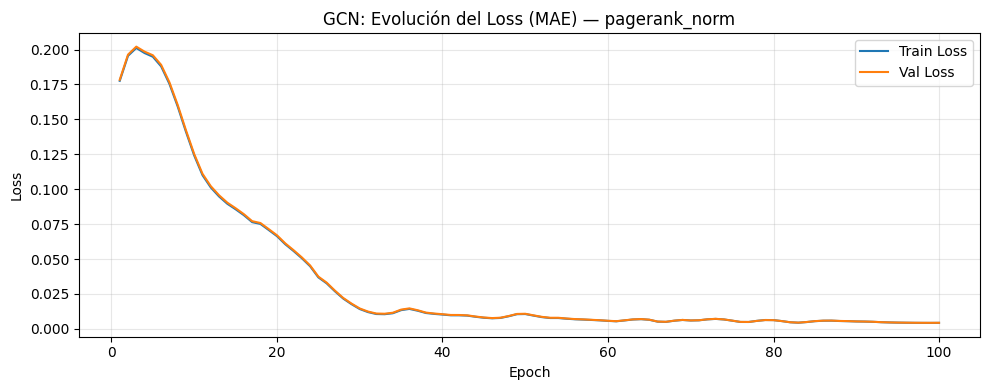

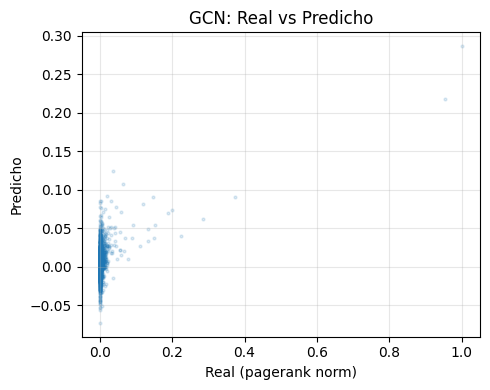


  [Métricas GCN]
  Best Val MAE : 0.004293
  Test MAE     : 0.004311
  Test R²      : 0.131347
  Guardado: embeddings_ribs_GCN_pagerank_norm.pt


Training model: GraphSAGE ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.738655  val=0.736237
  Epoch  10: train=0.091538  val=0.091140
  Epoch  20: train=0.045335  val=0.045559
  Epoch  30: train=0.052870  val=0.052748
  Epoch  40: train=0.031074  val=0.031062
  Epoch  50: train=0.019545  val=0.019673
  Epoch  60: train=0.014999  val=0.015021
  Epoch  70: train=0.013199  val=0.013205
  Epoch  80: train=0.011346  val=0.011456
  Epoch  90: train=0.010035  val=0.010138
  Epoch  99: train=0.009417  val=0.009516


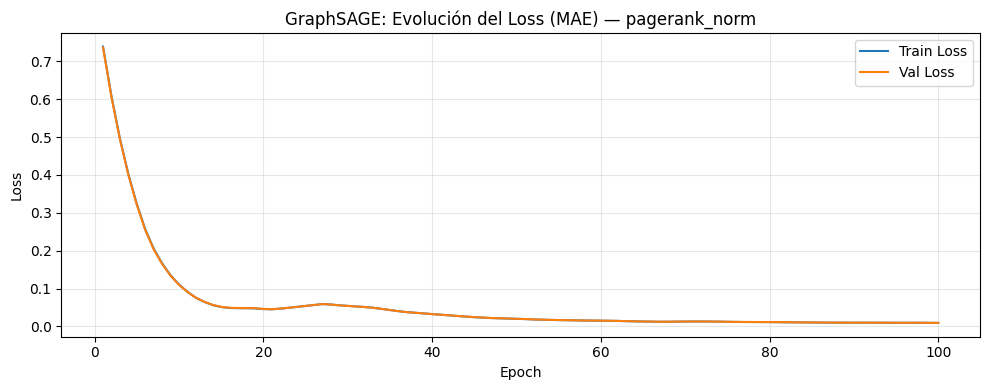

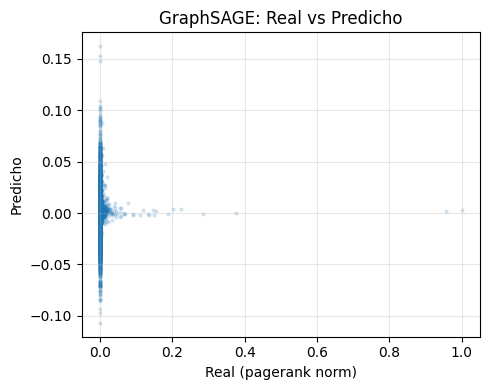


  [Métricas GraphSAGE]
  Best Val MAE : 0.009516
  Test MAE     : 0.009578
  Test R²      : -1.350268
  Guardado: embeddings_ribs_GraphSAGE_pagerank_norm.pt


Training model: GAT ----------------------------------------


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Epoch   0: train=0.331255  val=0.331495
  Epoch  10: train=0.222916  val=0.223565
  Epoch  20: train=0.059577  val=0.060001
  Epoch  30: train=0.020882  val=0.021148
  Epoch  40: train=0.018990  val=0.019170
  Epoch  50: train=0.014710  val=0.014903
  Epoch  60: train=0.010826  val=0.011348
  Epoch  70: train=0.009591  val=0.010222
  Epoch  80: train=0.008219  val=0.008740
  Epoch  90: train=0.007370  val=0.007801
  Epoch  99: train=0.006104  val=0.006490


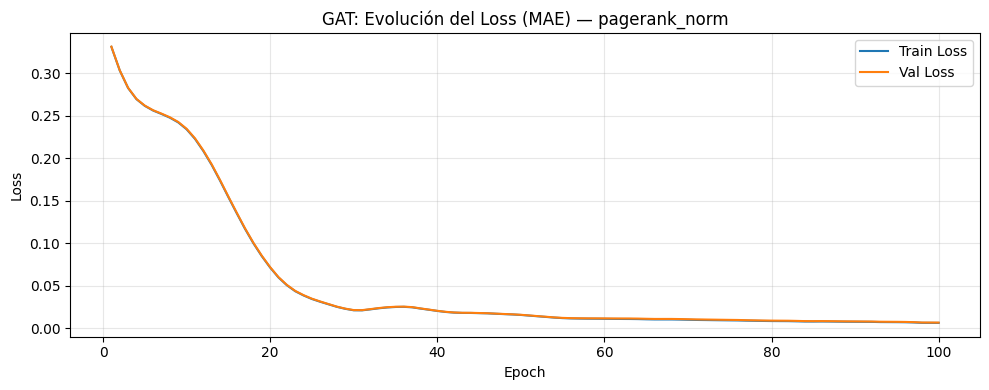

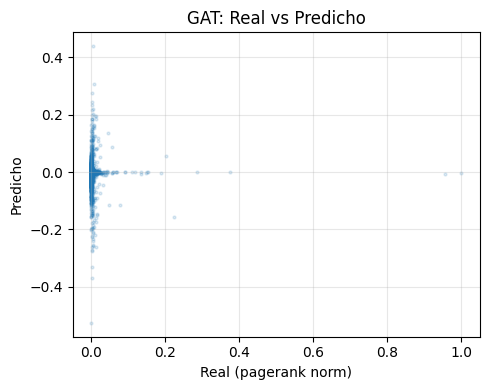


  [Métricas GAT]
  Best Val MAE : 0.006490
  Test MAE     : 0.006273
  Test R²      : -2.358079
  Guardado: embeddings_ribs_GAT_pagerank_norm.pt



In [38]:
attr     = 'pagerank_norm'
features = gnn.dgl_graph.ndata['feat']
labels   = gnn.dgl_graph.ndata['pagerank_norm']

# Split: 64% train / 16% val / 20% test
train_mask_orig     = gnn.dgl_graph.ndata['train_mask']
test_mask           = gnn.dgl_graph.ndata['test_mask']
train_indices       = torch.where(train_mask_orig)[0]
g_seed              = torch.Generator().manual_seed(42)
perm                = torch.randperm(len(train_indices), generator=g_seed)
n_val               = int(0.2 * len(train_indices))
val_indices         = train_indices[perm[:n_val]]
train_indices_final = train_indices[perm[n_val:]]
val_mask  = torch.zeros(gnn.dgl_graph.num_nodes(), dtype=torch.bool)
val_mask[val_indices] = True
train_mask = torch.zeros(gnn.dgl_graph.num_nodes(), dtype=torch.bool)
train_mask[train_indices_final] = True
print(f'Split => Train: {train_mask.sum()} | Val: {val_mask.sum()} | Test: {test_mask.sum()}')

in_feats      = features.shape[1]
hidden_feats  = 64
out_feats     = 32
out_feats_mlp = 1
lr            = 1e-3
NUM_EPOCHS    = 100
PATIENCE      = 20
save_dir      = data_path + 'results/EnfoquePorPartes/Caso4'
os.makedirs(save_dir, exist_ok=True)

for model_name in models:
    print(f'\nTraining model: {model_name} ' + '-'*40)
    model = models[model_name](
        in_feats=in_feats, hidden_feats=hidden_feats,
        out_feats=out_feats, out_feats_mlp=out_feats_mlp)

    loss_fn   = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=False)

    train_losses, val_losses = [], []
    best_val_loss    = float('inf')
    best_state       = None
    patience_counter = 0

    for epoch in range(NUM_EPOCHS):
        model.train()
        pred = model(gnn.dgl_graph, features)
        loss = loss_fn(pred[train_mask], labels[train_mask])
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_eval = model(gnn.dgl_graph, features)
            train_mae = loss_fn(pred_eval[train_mask], labels[train_mask]).item()
            val_mae   = loss_fn(pred_eval[val_mask],   labels[val_mask]).item()
        train_losses.append(train_mae)
        val_losses.append(val_mae)
        scheduler.step(val_mae)

        if epoch % 10 == 0 or epoch == NUM_EPOCHS - 1:
            print(f'  Epoch {epoch:3d}: train={train_mae:.6f}  val={val_mae:.6f}')

        if val_mae < best_val_loss:
            best_val_loss    = val_mae
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping epoch {epoch}. Best val MAE: {best_val_loss:.6f}')
            break

    model.load_state_dict(best_state)
    model.eval()

    plot_loss_evolution(train_losses, len(train_losses),
                        title=f'{model_name}: Evolución del Loss (MAE) — pagerank_norm',
                        val_losses=val_losses)

    with torch.no_grad():
        pred_final = model(gnn.dgl_graph, features)
        embeddings = model.encode(gnn.dgl_graph, features)

    pred_test   = pred_final[test_mask].cpu().numpy().flatten()
    labels_test = labels[test_mask].cpu().numpy().flatten()
    test_mae    = loss_fn(pred_final[test_mask], labels[test_mask]).item()
    r2          = r2_score(labels_test, pred_test)

    plt.figure(figsize=(5, 4))
    plt.scatter(labels_test, pred_test, alpha=0.15, s=4)
    plt.xlabel('Real (pagerank norm)')
    plt.ylabel('Predicho')
    plt.title(f'{model_name}: Real vs Predicho')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n  [Métricas {model_name}]')
    print(f'  Best Val MAE : {best_val_loss:.6f}')
    print(f'  Test MAE     : {test_mae:.6f}')
    print(f'  Test R\u00b2      : {r2:.6f}')

    torch.save(model.state_dict(),
               f'{save_dir}/model_emb_{model_name}_{attr}.pth')
    torch.save(embeddings,
               f'{save_dir}/embeddings_ribs_{model_name}_{attr}.pt')
    print(f'  Guardado: embeddings_ribs_{model_name}_{attr}.pt')
    print()


MLP

In [36]:
# Guardar los mismos embeddings con el prefijo 'mlp' para mantener
# la convención de nombres usada en Caso 0 / Caso 1.
# El entrenamiento es node-regression en ambas variantes; el sufijo
# indica la nomenclatura del decoder simbólico del enfoque staged.

save_dir = data_path + 'results/EnfoquePorPartes/Caso4'
attr     = 'pagerank_norm'

for model_name in ['GCN', 'GraphSAGE', 'GAT']:
    src_path = f'{save_dir}/embeddings_ribs_{model_name}_{attr}.pt'
    dst_path = f'{save_dir}/embeddings_mlp_{model_name}_{attr}.pt'
    if os.path.exists(src_path):
        import shutil
        shutil.copy2(src_path, dst_path)
        print(f'  Copiado: embeddings_mlp_{model_name}_{attr}.pt')
    else:
        print(f'  [AVISO] No encontrado: {src_path}  — ejecuta la celda anterior primero.')


  Copiado: embeddings_mlp_GCN_pagerank_norm.pt
  Copiado: embeddings_mlp_GraphSAGE_pagerank_norm.pt
  Copiado: embeddings_mlp_GAT_pagerank_norm.pt


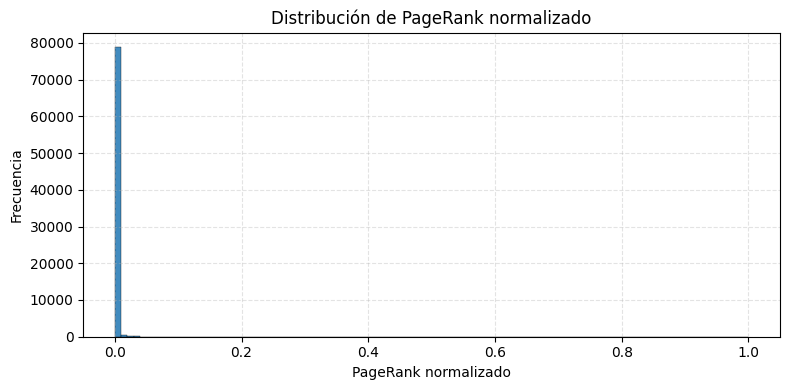

In [39]:


# Distribución de PageRank normalizado (min-max)
pr_norm = gnn.dgl_graph.ndata['pagerank_norm'].squeeze().detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.hist(pr_norm, bins=100, alpha=0.85, edgecolor='black', linewidth=0.3)
plt.title('Distribución de PageRank normalizado')
plt.xlabel('PageRank normalizado')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()



### Caso 5: Creación de embeddings a partir de DeepWalk y BGP2Vec 

### Caso 5.1: DeepWalk

In [11]:
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))
NUM_EPOCHS = 100


Grafo cargado: 79504 nodos, 734381 aristas
Dimensión de entrada (in_feats): 72


In [ ]:
# Configuración del modelo DeepWalk
# -------------------------------------
model = DeepWalk(
    gnn.dgl_graph,
    emb_dim=32,
    walk_length=40,
    window_size=1
)

# DataLoader para muestreo de caminatas aleatorias
# -------------------------------------------------
# Usar explícitamente el DataLoader de PyTorch (no el de DGL)
import torch.utils.data
dataloader = torch.utils.data.DataLoader(
    torch.arange(gnn.dgl_graph.num_nodes()),
    batch_size=128,
    shuffle=True,
    collate_fn=model.sample
)

optimizer = SparseAdam(model.parameters(), lr=0.01)

# Entrenamiento
# -------------------------------------
losses = []

print("=" * 60)
print("Iniciando entrenamiento de DeepWalk...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    num_batches = 0
    
    for batch_walk in dataloader:
        # Identificar cuáles filas NO tienen -1 (caminatas válidas)
        valid_mask = ~(batch_walk == -1).any(dim=1)
        
        # Filtrar filas válidas
        batch_walk_clean = batch_walk[valid_mask]
        
        # Si no hay caminatas válidas en el batch, continuar
        if batch_walk_clean.size(0) == 0:
            continue

        # Forward + backward
        loss = model(batch_walk_clean)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    # Calcular pérdida promedio de la época
    avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
    losses.append(avg_loss)
    
    # Mostrar progreso
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS}: Loss = {avg_loss:.6f}")

print("\n" + "=" * 60)
print("Entrenamiento completado!")
print("=" * 60)

# Obtener embeddings finales
# -------------------------------------
embeddings = model.node_embed.weight.detach().cpu()

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Número de nodos: {gnn.dgl_graph.num_nodes()}")
print(f"Dimensión de embeddings: {embeddings.shape[1]}")
print(f"\nLoss inicial: {losses[0]:.6f}")
print(f"Loss final: {losses[-1]:.6f}")
print(f"Reducción: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")

# 38 min
# 35 min

Iniciando entrenamiento de DeepWalk...
Epoch   1/100: Loss = 2.635218
Epoch  10/100: Loss = 0.808704
Epoch  20/100: Loss = 0.782633
Epoch  30/100: Loss = 0.772511
Epoch  40/100: Loss = 0.766229
Epoch  50/100: Loss = 0.762217
Epoch  60/100: Loss = 0.758485
Epoch  70/100: Loss = 0.755771
Epoch  80/100: Loss = 0.755317
Epoch  90/100: Loss = 0.753603
Epoch 100/100: Loss = 0.750525

Entrenamiento completado!

Embeddings shape: torch.Size([79504, 32])
Número de nodos: 79504
Dimensión de embeddings: 32

Loss inicial: 2.635218
Loss final: 0.750525
Reducción: 71.52%


Evolución del Loss durante el entrenamiento

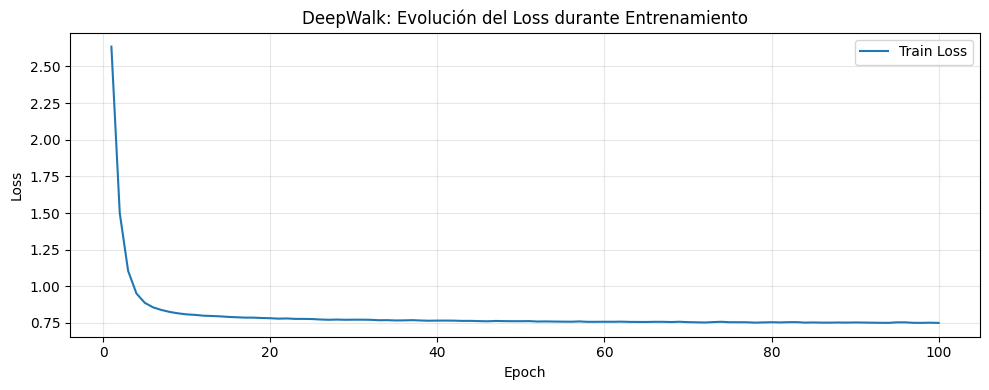

In [18]:
plot_loss_evolution(losses, NUM_EPOCHS, title='DeepWalk: Evolución del Loss durante Entrenamiento')

In [19]:
MES = "marzo"
ANO = "2026"

In [20]:
# Crear directorio si no existe
import os
save_dir = data_path + 'results/EnfoquePorPartes/Caso5/'
os.makedirs(save_dir, exist_ok=True)

# Guardar los embeddings
embeddings_path = save_dir + f'embeddings_deepWalk_{MES}_{ANO}.pt'
torch.save(embeddings, embeddings_path)

# Guardar el modelo completo
model_path = save_dir + f'model_deepWalk_{MES}_{ANO}.pth'
torch.save(model.state_dict(), model_path)

print('=' * 60)
print('ARCHIVOS GUARDADOS')
print('=' * 60)
print(f'Embeddings guardados en: {embeddings_path}')
print(f'Modelo guardado en: {model_path}')
print(f'\nShape embeddings: {embeddings.shape}')


ARCHIVOS GUARDADOS
Embeddings guardados en: /media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/embeddings_deepWalk_marzo_2026.pt
Modelo guardado en: /media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/model_deepWalk_marzo_2026.pth

Shape embeddings: torch.Size([79504, 32])


### Caso 5.2 BGP2Vec

In [8]:
from gensim.models import Word2Vec


In [9]:
MODELS_PATH = data_path + 'results/EnfoquePorPartes/Caso5/'
print(f"[Modelos guardados en]: {MODELS_PATH}]")
print(f"[Archivo con RIBs]: {ribs_file}")



[Modelos guardados en]: /media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/]
[Archivo con RIBs]: /media/vale/KINGSTON/TESIS/data_2026//rib_20260301_0000_to_20260302_0000.txt


#### Importar rutas BGP 

In [ ]:
from modules.bgp2vec import RIBCorpus
import itertools

# Configuración
MAX_ROUTES_TRAIN = 1_000_000   # None => usar todas las rutas
COUNT_ALL_ROUTES = False       # True => recorre todo el archivo para contar

# Muestra pequeña para verificar formato
sample = list(itertools.islice(RIBCorpus(ribs_file, skip_header=True), 10))
print("[RUTAS BGP - MUESTRA]:", sample)

# Conteo total opcional (puede tardar porque recorre todo)
if COUNT_ALL_ROUTES:
    count_routes = sum(1 for _ in RIBCorpus(ribs_file, skip_header=True))
    print("[CANTIDAD TOTAL DE RUTAS BGP]:", count_routes)
else:
    print("[CANTIDAD TOTAL DE RUTAS BGP]: omitido (COUNT_ALL_ROUTES=False)")

# Corpus para entrenamiento: limitado o completo
if MAX_ROUTES_TRAIN is None:
    bgp_routes = RIBCorpus(ribs_file, skip_header=True)
    print("[RUTAS PARA ENTRENAR]: todas")
else:
    bgp_routes = itertools.islice(RIBCorpus(ribs_file, skip_header=True), MAX_ROUTES_TRAIN)
    print(f"[RUTAS PARA ENTRENAR]: primeras {MAX_ROUTES_TRAIN}")

print("[TIPO]:", type(bgp_routes))

Warning! PYTHONHASHSEED is not defined


NameError: name 'ribs_file' is not defined

#### Crear Embeddings

In [7]:
MODELS_PATH = data_path + 'results/EnfoquePorPartes/Caso5/'

In [8]:
test_limit = 27000000 #cantidad paths/horaciones
mode = None# 'test' # par limitar cantidad de paths/oraciones
epochs = 1
debug = True

# Crea embeddings de ASN con  BGP2VEC y lo guarda en "bgp2vec/bgp2vec.word2vec"
bgp2vec = BGP2VEC(model_path = MODELS_PATH + 'bgp2vec.word2vec',
                  bgp_routes=bgp_routes,
                  rewrite=True, 
                  test_limit= test_limit, 
                  mode = mode, 
                  epochs = epochs)

print("[MODELO]",bgp2vec.model)
print("[NUMERO ASN REPETIDOS Y TODO]",bgp2vec.model.corpus_total_words)

# 1.000.000 -> 7 seg
# 2.000.000 -> 14 seeg
# todo el dataset (27.000.000) -> 5 min

[MODELO] Word2Vec<vocab=79504, vector_size=32, alpha=0.025>
[NUMERO ASN REPETIDOS Y TODO] 146331993


In [9]:
# Importar embeddings preentrenado de los ASN  con BGP2VEC
BGP2Vec_model = Word2Vec.load(MODELS_PATH + "bgp2vec.word2vec")

# Obtener la matriz de embeddings
embeddings = BGP2Vec_model.wv.vectors
total_ASNs, embedding_vecor_length = embeddings.shape


print(f"[TOTAL ASN]: {total_ASNs}" )
print(f"[EMBEDDINGS LEN]: {embedding_vecor_length}")
print(f"[EMBEDDINGS] {embeddings}")

[TOTAL ASN]: 79504
[EMBEDDINGS LEN]: 32
[EMBEDDINGS] [[-0.5793098  -0.7366217   0.06125731 ...  0.06648978 -1.1286678
   0.32657403]
 [-0.34173593 -0.58233196 -0.278572   ...  0.14392011 -0.845983
  -0.41935155]
 [-0.36501932 -0.11620948  0.29416117 ... -0.33362213 -0.99145776
   0.00467851]
 ...
 [ 0.01637959 -0.03217693 -0.00332681 ... -0.00659135  0.01250625
  -0.0151147 ]
 [ 0.02865581 -0.02761246  0.01732459 ...  0.02264958  0.00731843
   0.00589193]
 [-0.01428418  0.00691889 -0.00665132 ... -0.01195079 -0.00696451
  -0.01532075]]


In [11]:
# Mapeo ASN -> ID usado en los embeddings
asn_to_index = BGP2Vec_model.wv.key_to_index
print(f"[ASN TO INDEX]: {asn_to_index}")
print(f"[TAMANO]: {len(asn_to_index)}")

[ASN TO INDEX]: {'3356': 0, '6939': 1, '1299': 2, '174': 3, '2914': 4, '6453': 5, '3257': 6, '6461': 7, '6762': 8, '3491': 9, '32590': 10, '12956': 11, '9002': 12, '52468': 13, '9498': 14, '199524': 15, '4637': 16, '37468': 17, '60539': 18, '137409': 19, '8529': 20, '37100': 21, '7195': 22, '16552': 23, '8220': 24, '12389': 25, '7018': 26, '49544': 27, '52320': 28, '4826': 29, '30844': 30, '398465': 31, '264409': 32, '4755': 33, '5511': 34, '49666': 35, '3216': 36, '2497': 37, '22381': 38, '1031': 39, '6830': 40, '53062': 41, '61568': 42, '17350': 43, '1221': 44, '14537': 45, '16735': 46, '3320': 47, '13786': 48, '19529': 49, '14840': 50, '8888': 51, '61832': 52, '28329': 53, '63956': 54, '13335': 55, '34927': 56, '7713': 57, '4230': 58, '267613': 59, '3741': 60, '25091': 61, '37662': 62, '60068': 63, '209': 64, '58453': 65, '15830': 66, '701': 67, '58717': 68, '32653': 69, '2152': 70, '1273': 71, '18403': 72, '7922': 73, '55655': 74, '271253': 75, '8708': 76, '37271': 77, '4764': 78, 

## Clasificación Aristas 

In [34]:
# !pip uninstall gensim -y 
# %pip install gensim==4.3.3

In [35]:
# !pip install scikit-learn
# !pip install numpy
# !pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
# # !pip uninstall tensorflow -y
# !pip install tensorflow==2.17.0
# !pip install matplotlib
# !pip install  dgl -f https://data.dgl.ai/wheels/torch-2.3/cu121/repo.html



In [12]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.insert(0, os.path.abspath("../.."))
import numpy as np
from collections import Counter
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
import torch



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
TOR_LABELS_DICT = {'P2P':0, 'C2P': 1,'P2C': 2}
TOR_CSV_LABELS_DICT = {'P2P':0,'P2C': -1}

TESIS_PATH  = '/media/vale/KINGSTON/TESIS/'
class_names = ['P2P', 'C2P', 'P2C']

# Dataset entrenamiento RNA para relaciones entre AS
MODEL_NAME = 'NN_Inference'
MES = 'marzo'



## Importar Emberddings

In [10]:
# Seleccionar embeddings a cargar
# Descomenta el bloque del caso que quieras usar

# # # ─── Caso 0: link prediction, atributos PeeringDB (mis_attr_marzo) ───────────
attr = 'mis_attr_marzo'
CASO = "Caso0"
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GCN_mis_attr_marzo.pt'


# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GraphSAGE_mis_attr_marzo.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GAT_mis_attr_marzo.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GCN_mis_attr_marzo.pt'
embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GraphSAGE_mis_attr_marzo.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GAT_mis_attr_marzo.pt'

# ─── Caso 1: link prediction, atributos grado entrada/salida ──────────────────
# attr = 'grado_attr_febrero'
# CASO = 'Caso1'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GCN_grado_attr_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GraphSAGE_grado_attr_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_DotProduct_GAT_grado_attr_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}//embeddings_ribs_MLP_GCN_grado_attr_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GraphSAGE_grado_attr_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_MLP_GAT_grado_attr_febrero.pt'

# ─── Caso 3: regresión grado de salida ───────────────────────────────────────
# attr = 'out_degree'
# CASO = 'Caso3'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GCN_out_degree.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GraphSAGE_out_degree.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GAT_out_degree.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GCN_out_degree_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GraphSAGE_out_degree_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GAT_out_degree_febrero.pt'

# ─── Caso 4: regresión PageRank ───────────────────────────────────────────────
# attr = 'pagerank_norm'
# CASO = 'Caso4'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GCN_pagerank_norm.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GraphSAGE_pagerank_norm.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GAT_pagerank_norm.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GCN_pagerank_norm_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GraphSAGE_pagerank_norm_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_ribs_GAT_pagerank_norm_febrero.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_mlp_GCN_pagerank_norm.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_mlp_GraphSAGE_pagerank_norm.pt'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_mlp_GAT_pagerank_norm.pt'

# ─── Caso 5.1: DeepWalk ─────────────────────────────────────────────────────────
# attr = 'deepWalk'
# CASO = 'Caso5'
# embeddings_path = data_path +  f'results/EnfoquePorPartes/{CASO}/embeddings_deepWalk_marzo_2026.pt'
# embeddings_path =  "/home/vale/Escritorio/GIT/TrabajoTesis/results/EnfoquePorPartes/Caso5/embeddings_deepWalk_marzo_2026.pt"
# # Modelo guardado en: /home/vale/Escritorio/GIT/TrabajoTesis/results/EnfoquePorPartes/Caso5/model_deepWalk_marzo_2026.pth
# print('Cargando:', embeddings_path)

# ─── Caso 5.2: BGP2Vec ───────────────────────────────────────────────

# Caso 5: BGP2Vvec
attr = 'bgp2vec'
CASO = "Caso5"

save_dir = data_path + 'results/EnfoquePorPartes/Caso5/'
embeddings_path = data_path + 'results/EnfoquePorPartes/Caso5/bgp2vec.word2vec'



In [33]:
save_dir

'/media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/'

In [12]:
save_dir = data_path + f'results/EnfoquePorPartes/{CASO}/'

if attr != 'bgp2vec':
    print ("=" * 60)
    print(f"Cargando embeddings de: {embeddings_path}")
    print ("=" * 60)
    embeddings_name = embeddings_path.split('/')[-1].split('.')[0]  # Nombre del archivo sin extensión
    embeddings_pt = torch.load(embeddings_path)  # asegúrate que sea un tensor
    embeddings = embeddings_pt.detach().numpy()

if attr == 'bgp2vec':
    # Si son los mbddings de BGP2Vec, cargamos con gensim
    print ("=" * 60)
    print(f"Cargando embeddings BGP2Vec: {embeddings_path}")
    print ("=" * 60)
    embeddings_name = "bgp2vec"  # Nombre del archivo sin extensión

    BGP2Vec_model = Word2Vec.load(embeddings_path)

    # Obtener la matriz de embeddings
    embeddings = BGP2Vec_model.wv.vectors

    asn_to_index = BGP2Vec_model.wv.key_to_index
    print(f"[ASN TO INDEX]: {asn_to_index}")
    print(f"[TAMANO]: {len(asn_to_index)}")

total_ASNs, embedding_vecor_length = embeddings.shape


print(f"[TOTAL ASN]: {total_ASNs}" )
print(f"[EMBEDDINGS LEN]: {embedding_vecor_length}")
print(f"[EMBEDDINGS] {embeddings}")





Cargando embeddings BGP2Vec: /media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/bgp2vec.word2vec
[ASN TO INDEX]: {'3356': 0, '6939': 1, '1299': 2, '174': 3, '2914': 4, '6453': 5, '3257': 6, '6461': 7, '6762': 8, '3491': 9, '32590': 10, '12956': 11, '9002': 12, '52468': 13, '9498': 14, '199524': 15, '4637': 16, '37468': 17, '60539': 18, '137409': 19, '8529': 20, '37100': 21, '7195': 22, '16552': 23, '8220': 24, '12389': 25, '7018': 26, '49544': 27, '52320': 28, '4826': 29, '30844': 30, '398465': 31, '264409': 32, '4755': 33, '5511': 34, '49666': 35, '3216': 36, '2497': 37, '22381': 38, '1031': 39, '6830': 40, '53062': 41, '61568': 42, '17350': 43, '1221': 44, '14537': 45, '16735': 46, '3320': 47, '13786': 48, '19529': 49, '14840': 50, '8888': 51, '61832': 52, '28329': 53, '63956': 54, '13335': 55, '34927': 56, '7713': 57, '4230': 58, '267613': 59, '3741': 60, '25091': 61, '37662': 62, '60068': 63, '209': 64, '58453': 65, '15830': 66, '701': 67, '58717': 68, '32653': 69,

## Clasificación de Tipos de Enlace con ANN

Se cargan los embeddings GNN ya entrenados y el dataset ToR (pares de ASNs con etiqueta P2P/C2P/P2C).
Para cada par (ASN_u, ASN_v) se construye un vector de arista **[e_u | e_v | e_u−e_v | e_u·e_v]** que se pasa a un clasificador MLP.

El notebook está organizado en:
1. Carga y exploración del dataset ToR
2. Mapeo ASN → node_id y construcción vectorizada de features de arista
3. Definición del modelo ANN
4. Entrenamiento **sin batches** (dataset completo en memoria)
5. Entrenamiento **con batches** (DataLoader)
6. Evaluación final: accuracy, reporte por clase, matrices de confusión

### 1. Configuración

In [ ]:
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import TensorDataset, DataLoader

MES  = 'marzo'
ANO  = '2026'
TESIS_PATH = '/media/vale/KINGSTON/TESIS/'
TOR_PATH   = TESIS_PATH + f'data_2026/ToR_data/tor_data_{MES}/'

CLASS_NAMES = ['P2P', 'C2P', 'P2C']
N_CLASSES   = 3

# Hiperparámetros ANN
ANN_HIDDEN   = 256
ANN_DROPOUT  = 0.3
ANN_LR       = 1e-3
ANN_EPOCHS   = 20
ANN_PATIENCE = 20
ANN_BATCH    = 4096
VAL_SIZE     = 0.2



### 2. Cargar Dataset ToR

In [14]:
# x contiene pares de ASNs (strings), y contiene etiquetas 0/1/2
x_train_raw = np.load(TOR_PATH + 'x_training.npy')          # (N, 2) dtype=str
x_test_raw  = np.load(TOR_PATH + 'x_test.npy')
y_train_raw = np.load(TOR_PATH + 'y_training.npy').astype(int)
y_test_raw  = np.load(TOR_PATH + 'y_test.npy').astype(int)

print(f'Train: {x_train_raw.shape}  dtype={x_train_raw.dtype}')
print(f'Test:  {x_test_raw.shape}')
print(f'Distribución y_train: {dict(sorted(Counter(y_train_raw.tolist()).items()))}')
print(f'Distribución y_test:  {dict(sorted(Counter(y_test_raw.tolist()).items()))}')
print(f'Ejemplo x_train[0]: ASN_u={x_train_raw[0,0]}  ASN_v={x_train_raw[0,1]}')


Train: (805489, 2)  dtype=<U6
Test:  (201373, 2)
Distribución y_train: {0: 543374, 1: 130893, 2: 131222}
Distribución y_test:  {0: 135788, 1: 32957, 2: 32628}
Ejemplo x_train[0]: ASN_u=6853  ASN_v=39120


### 3. Mapeo ASN → node_id y Features de Arista

Los embeddings están indexados por `node_id` (fila en el grafo DGL), pero el dataset ToR usa ASNs.
Se carga el CSV de nodos para construir el diccionario `asn → node_id`.

In [15]:
if attr != 'bgp2vec':
    print ("=" * 60)
    print(f"Mapeo de nodos en el grafo a partir del CSV de nodos: {nodes_file}")
    print ("=" * 60)

    # Construir mapeo {asn(int) -> node_id(int)} desde el CSV de nodos
    nodes_df = pd.read_csv(str(nodes_file))
    asn_to_nodeid = dict(zip(nodes_df['asn'].astype(int), nodes_df['node_id'].astype(int)))

if attr == 'bgp2vec':
    print ("=" * 60)
    print(f"Mapeo de nodos en el grafo a partir de bgp2vec: {nodes_file}")
    print ("=" * 60)

    raw_index = BGP2Vec_model.wv.key_to_index
    asn_to_nodeid = {}
    invalid_tokens = []

    for k, v in raw_index.items():
        k_str = str(k).strip()
        if not k_str:
            invalid_tokens.append(k)
            continue
        try:
            asn_to_nodeid[int(k_str)] = v
        except ValueError:
            invalid_tokens.append(k)

    print(f"[ASN válidos]: {len(asn_to_nodeid):,}")
    print(f"[ASN inválidos descartados]: {len(invalid_tokens):,}")
    if invalid_tokens:
        print(f"[Muestra inválidos]: {invalid_tokens[:10]}")

print(f'[Nodos en el grafo]:    {len(asn_to_nodeid):,}')
print(f'[ASNs en x_train]:      {len(set(x_train_raw.flatten())):,} únicos')

# Cobertura: ¿cuántos ASNs del ToR están en el grafo?
asns_tor = set(int(a) for a in x_train_raw.flatten())
covered = asns_tor & set(asn_to_nodeid.keys())
print(f'[Cobertura]:            {len(covered):,} / {len(asns_tor):,} ({len(covered)/len(asns_tor)*100:.1f}%)')

Mapeo de nodos en el grafo a partir de bgp2vec: /media/vale/KINGSTON/TESIS/data_2026//nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv
[ASN válidos]: 79,504
[ASN inválidos descartados]: 0
[Nodos en el grafo]:    79,504
[ASNs en x_train]:      77,905 únicos
[ASNs en x_train]:      77,905 únicos
[Cobertura]:            77,720 / 77,905 (99.8%)
[Cobertura]:            77,720 / 77,905 (99.8%)


In [16]:
def build_edge_features(x_pairs, emb_tensor, asn_to_nodeid):
    """
    Construye features de arista [e_u | e_v | e_u-e_v | e_u*e_v] de forma vectorizada.

    Args:
        x_pairs       : (N, 2) array de ASNs (strings o ints)
        emb_tensor    : (num_nodes, emb_dim) float tensor o numpy array
        asn_to_nodeid : dict {asn(int|str) -> node_id(int)}

    Returns:
        feats  : (M, 4*emb_dim) float tensor  (M <= N, solo pares válidos)
        valid  : (N,) bool array  (True si ambos ASNs están en el grafo)
    """
    # Asegurar tensor PyTorch para operaciones posteriores (torch.cat)
    emb_tensor = torch.as_tensor(emb_tensor, dtype=torch.float32)

    def _lookup_nid(asn_val):
        asn_int = int(asn_val)
        # Compatibilidad: diccionarios con claves int (GNN) o str (BGP2Vec)
        return asn_to_nodeid.get(asn_int, asn_to_nodeid.get(str(asn_int), -1))

    nid_u = np.array([_lookup_nid(a) for a in x_pairs[:, 0]], dtype=np.int64)
    nid_v = np.array([_lookup_nid(a) for a in x_pairs[:, 1]], dtype=np.int64)
    valid = (nid_u >= 0) & (nid_v >= 0)

    # Si no hay pares válidos, devolver tensor vacío con dimensión correcta
    if valid.sum() == 0:
        empty_feats = torch.empty((0, emb_tensor.shape[1] * 4), dtype=emb_tensor.dtype)
        return empty_feats, valid

    idx_u = torch.as_tensor(nid_u[valid], dtype=torch.long)
    idx_v = torch.as_tensor(nid_v[valid], dtype=torch.long)

    e_u = emb_tensor[idx_u]          # (M, D)
    e_v = emb_tensor[idx_v]          # (M, D)
    feats = torch.cat([e_u, e_v, e_u - e_v, e_u * e_v], dim=1)  # (M, 4D)
    return feats, valid


# embeddings cargado en la sección 'Importar Embeddings' (celdas anteriores)
emb_tensor = torch.as_tensor(embeddings, dtype=torch.float32)
emb_dim    = emb_tensor.shape[1]
print(f'Embeddings: {tuple(emb_tensor.shape)}  →  features por arista: {4 * emb_dim}')

print('Construyendo features de entrenamiento...')
X_train_feat, train_valid = build_edge_features(x_train_raw, emb_tensor, asn_to_nodeid)
y_train_feat = y_train_raw[train_valid]
print(f'  {x_train_raw.shape[0]:,} pares → {train_valid.sum():,} válidos '
      f'({train_valid.mean()*100:.1f}%)')

print('Construyendo features de test...')
X_test_feat, test_valid = build_edge_features(x_test_raw, emb_tensor, asn_to_nodeid)
y_test_feat = y_test_raw[test_valid]
print(f'  {x_test_raw.shape[0]:,} pares → {test_valid.sum():,} válidos '
      f'({test_valid.mean()*100:.1f}%)')

Embeddings: (79504, 32)  →  features por arista: 128
Construyendo features de entrenamiento...
  805,489 pares → 796,765 válidos (98.9%)
Construyendo features de test...
  805,489 pares → 796,765 válidos (98.9%)
Construyendo features de test...
  201,373 pares → 199,261 válidos (99.0%)
  201,373 pares → 199,261 válidos (99.0%)


### 4. Preparar Tensores y Pesos de Clase

In [17]:
# Train / Val split estratificado (80/20 del training)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_feat, y_train_feat,
    test_size=VAL_SIZE, random_state=42, stratify=y_train_feat)

y_tr_t  = torch.tensor(y_tr,  dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_te_t  = torch.tensor(y_test_feat, dtype=torch.long)

print(f'Train: {len(X_tr):,}  Val: {len(X_val):,}  Test: {len(X_test_feat):,}')
print(f'y_tr  dist: {dict(sorted(Counter(y_tr.tolist()).items()))}')

# Pesos de clase para compensar desbalance P2P >> C2P, P2C
cw = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr)
class_weights = torch.tensor(cw, dtype=torch.float)
print(f'Class weights: P2P={cw[0]:.3f}  C2P={cw[1]:.3f}  P2C={cw[2]:.3f}')


Train: 637,412  Val: 159,353  Test: 199,261
y_tr  dist: {0: 428985, 1: 104081, 2: 104346}
Class weights: P2P=0.495  C2P=2.041  P2C=2.036


### 5. Definición del Modelo ANN

El vector de entrada es **[e_u | e_v | e_u−e_v | e_u·e_v]** (4×emb_dim).
La diferencia y el producto capturan la **asimetría direccional** necesaria para separar C2P de P2C.

In [18]:
class EdgeClassifierANN(nn.Module):
    """
    MLP que clasifica el tipo de enlace AS (P2P / C2P / P2C)
    a partir del vector de arista [e_u | e_v | e_u-e_v | e_u*e_v].
    """
    def __init__(self, emb_dim, n_classes=3, hidden=256, dropout=0.3):
        super().__init__()
        in_dim = 4 * emb_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, x):    # x: (batch, 4*emb_dim)
        return self.net(x)


# Verificar dimensiones
_m = EdgeClassifierANN(emb_dim, N_CLASSES, ANN_HIDDEN, ANN_DROPOUT)
_x = torch.randn(4, 4 * emb_dim)
print(f'Test forward: input={_x.shape}  output={_m(_x).shape}')
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {n_params:,}')
del _m, _x


Test forward: input=torch.Size([4, 128])  output=torch.Size([4, 3])
Parámetros entrenables: 67,075


### 6. Entrenamiento Sin Batches

Todo el conjunto de entrenamiento se pasa de una vez en cada época. Funciona bien si los datos caben en GPU/RAM.

### 7. Entrenamiento Con Batches (DataLoader)

Más eficiente en memoria y con mejor generalización gracias al ruido de mini-batch.

In [26]:
loss_fn_b = nn.CrossEntropyLoss(weight=class_weights)
loss_fn_b = nn.CrossEntropyLoss()


ds_train   = TensorDataset(X_tr, y_tr_t)
ds_val     = TensorDataset(X_val, y_val_t)
loader_tr  = DataLoader(ds_train, batch_size=ANN_BATCH, shuffle=True,  drop_last=False)
loader_val = DataLoader(ds_val,   batch_size=ANN_BATCH * 4, shuffle=False)

model_b  = EdgeClassifierANN(emb_dim, N_CLASSES, ANN_HIDDEN, ANN_DROPOUT)
opt_b    = torch.optim.Adam(model_b.parameters(), lr=ANN_LR)
sched_b  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_b, mode='min', factor=0.5, patience=5, verbose=False)

train_losses_b, val_losses_b = [], []
best_val_b, best_state_b, patience_ctr_b = float('inf'), None, 0

print("=" * 60)
print(f'Con Batches (batch={ANN_BATCH}) ')
print("=" * 60)
for epoch in range(ANN_EPOCHS):
    # ── Train ──
    model_b.train()
    epoch_loss = 0
    for x_b, y_b in loader_tr:
        logits = model_b(x_b)
        loss   = loss_fn_b(logits, y_b)
        opt_b.zero_grad(); loss.backward(); opt_b.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(loader_tr)

    # ── Val ──
    model_b.eval()
    val_loss, n_correct = 0, 0
    with torch.no_grad():
        for x_b, y_b in loader_val:
            logits = model_b(x_b)
            val_loss  += loss_fn_b(logits, y_b).item()
            n_correct += (logits.argmax(1) == y_b).sum().item()
    avg_val  = val_loss / len(loader_val)
    val_acc  = n_correct / len(X_val)
    train_losses_b.append(avg_train)
    val_losses_b.append(avg_val)
    sched_b.step(avg_val)

    if epoch % 10 == 0 or epoch == ANN_EPOCHS - 1:
        print(f'  Epoch {epoch:3d}: train={avg_train:.4f}  '
              f'val={avg_val:.4f}  val_acc={val_acc*100:.2f}%')

    # ── Early stopping ──
    if avg_val < best_val_b:
        best_val_b   = avg_val
        best_state_b = {k: v.clone() for k, v in model_b.state_dict().items()}
        patience_ctr_b = 0
    else:
        patience_ctr_b += 1
    if patience_ctr_b >= ANN_PATIENCE:
        print(f'  Early stopping epoch {epoch}.')
        break

model_b.load_state_dict(best_state_b)
print(f'Mejor val loss (con batches): {best_val_b:.4f}')



/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Con Batches (batch=4096) 
  Epoch   0: train=0.3123  val=0.1749  val_acc=94.12%
  Epoch   0: train=0.3123  val=0.1749  val_acc=94.12%
  Epoch  10: train=0.1262  val=0.1088  val_acc=96.38%
  Epoch  10: train=0.1262  val=0.1088  val_acc=96.38%
  Epoch  20: train=0.1104  val=0.0994  val_acc=96.74%
  Epoch  20: train=0.1104  val=0.0994  val_acc=96.74%
  Epoch  30: train=0.1036  val=0.0965  val_acc=96.85%
  Epoch  30: train=0.1036  val=0.0965  val_acc=96.85%
  Epoch  40: train=0.0989  val=0.0943  val_acc=96.91%
  Epoch  40: train=0.0989  val=0.0943  val_acc=96.91%
  Epoch  49: train=0.0956  val=0.0928  val_acc=96.96%
Mejor val loss (con batches): 0.0924
  Epoch  49: train=0.0956  val=0.0928  val_acc=96.96%
Mejor val loss (con batches): 0.0924


### 8. Evaluación Final

Se evalúa el modelo con batches (mejor opción) sobre el conjunto de test.

In [24]:
# Elegir modelo: con batches suele generalizar mejor
best_model = model_b  #model_nb

best_model.eval()
all_preds = []
loader_te = DataLoader(TensorDataset(X_test_feat), batch_size=ANN_BATCH * 4)
with torch.no_grad():
    for (x_b,) in loader_te:
        all_preds.append(best_model(x_b).argmax(1))
preds_test = torch.cat(all_preds).numpy()
y_te_np    = y_te_t.numpy()

print('=' * 60)
print('EVALUACIÓN EN TEST SET')
print('=' * 60)
print(f'Accuracy: {accuracy_score(y_te_np, preds_test)*100:.2f}%\n')
print(classification_report(y_te_np, preds_test, target_names=CLASS_NAMES))


EVALUACIÓN EN TEST SET
Accuracy: 95.82%

              precision    recall  f1-score   support

         P2P       0.99      0.96      0.97    134081
         C2P       0.90      0.96      0.93     32756
         P2C       0.90      0.96      0.93     32424

    accuracy                           0.96    199261
   macro avg       0.93      0.96      0.94    199261
weighted avg       0.96      0.96      0.96    199261



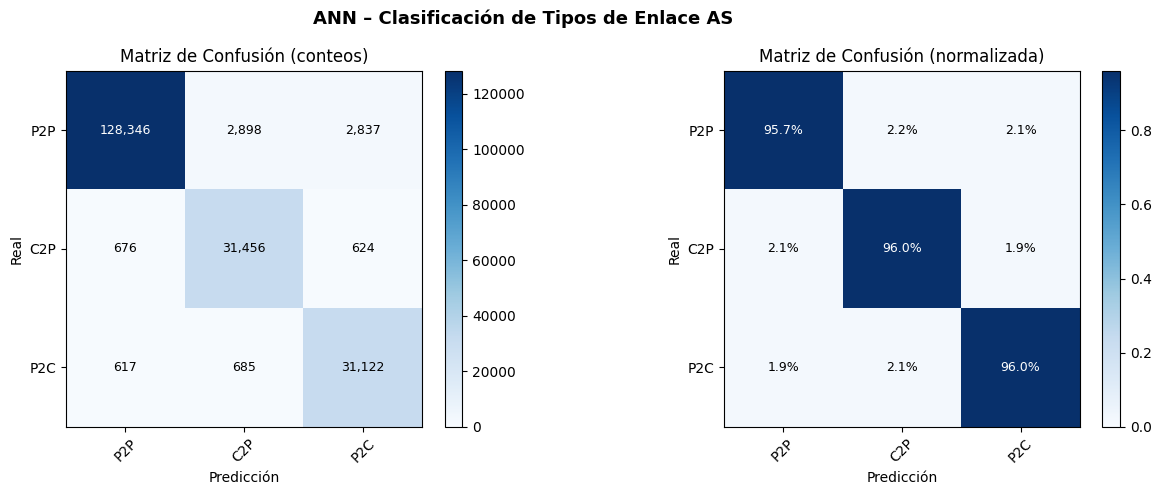

In [25]:
# ── Matrices de confusión ──
save_dir = data_path + f'results/EnfoquePorPartes/{CASO}/'
cm      = confusion_matrix(y_te_np, preds_test)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title, fmt in [
    (axes[0], cm,      'Matriz de Confusión (conteos)',       lambda v: f'{v:,}'),
    (axes[1], cm_norm, 'Matriz de Confusión (normalizada)',   lambda v: f'{v*100:.1f}%'),
]:
    im = ax.imshow(data, cmap='Blues', vmin=0)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real'); ax.set_title(title)
    thresh = data.max() / 2
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, fmt(data[i, j]), ha='center', va='center',
                    color='white' if data[i, j] > thresh else 'black', fontsize=9)

plt.suptitle('ANN – Clasificación de Tipos de Enlace AS', fontsize=13, fontweight='bold')
plt.tight_layout()
save_dir = save_dir + f'results/EnfoquePorPartes/{CASO}/'
os.makedirs(save_dir, exist_ok=True)
plt.savefig(save_dir + f"results/EnfoquePorPartes/{CASO}/" +'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



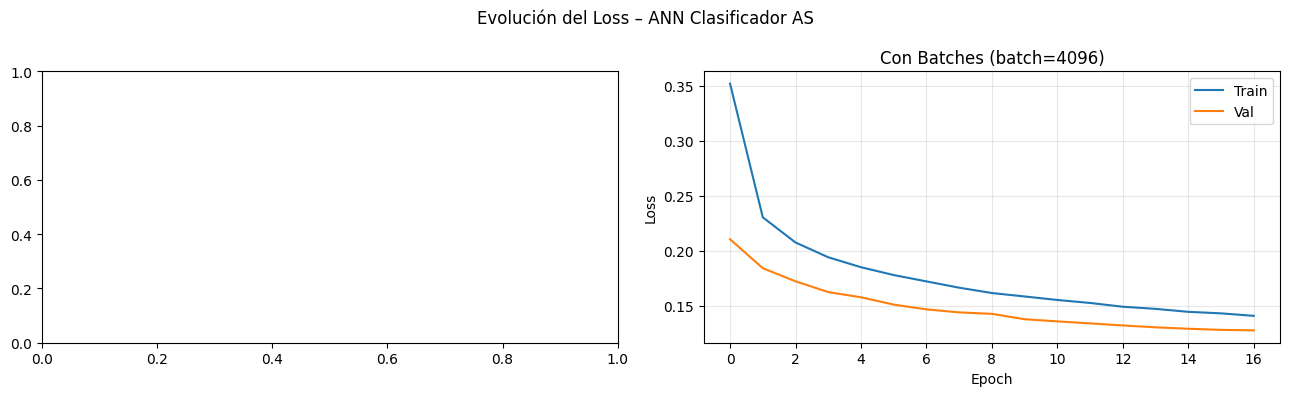

Modelos guardados en /media/vale/KINGSTON/TESIS/data_2026/results/EnfoquePorPartes/Caso5/results/EnfoquePorPartes/Caso5/


In [22]:
# ── Curvas de loss: sin batches vs con batches ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, tr, va, title in [
    # (axes[0], train_losses_nb, val_losses_nb, 'Sin Batches'),
    (axes[1], train_losses_b,  val_losses_b,  f'Con Batches (batch={ANN_BATCH})'),
]:
    ax.plot(tr, label='Train', linewidth=1.5)
    ax.plot(va, label='Val',   linewidth=1.5)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Evolución del Loss – ANN Clasificador AS', fontsize=12)
plt.tight_layout()
plt.savefig(save_dir + 'loss_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Guardar modelos ──
# torch.save(model_nb.state_dict(), save_dir + f'ann_sin_batches_{embeddings_name}.pth')
torch.save(model_b.state_dict(),  save_dir + f'ann_con_batches_{embeddings_name}.pth')
print(f'Modelos guardados en {save_dir}')


RESULTADOS:

BGP2Vec:
    * 270.000 ribs y 100 epochs y weihgt:
        Accuracy: 81.59%

                    precision    recall  f1-score   support

                P2P       0.96      0.80      0.88     81241
                C2P       0.59      0.85      0.69     15087
                P2C       0.59      0.86      0.70     15007

            accuracy                           0.82    111335
        macro avg       0.71      0.84      0.76    111335
        weighted avg       0.86      0.82      0.83    111335
    ----------------------------------
    * 1.000.000 ribs y 100 epochs y weihgt:
        * Tengo solamnte 50.112 la ANN descarata quellos nodos para los que no tiene un embdidngs. (por lo tanto está sesgada) 

        BGP2Vec:
    * 270.000 ribs y 100 epochs :
        Accuracy: 81.59%

                    precision    recall  f1-score   support

                P2P       0.96      0.80      0.88     81241
                C2P       0.59      0.85      0.69     15087
                P2C       0.59      0.86      0.70     15007

            accuracy                           0.82    111335
        macro avg       0.71      0.84      0.76    111335
        weighted avg       0.86      0.82      0.83    111335
    ----------------------------------
    * 1.000.000 ribs y 100 epochs y weihgt :
        * Tengo solamnte 50.112 la ANN descarata quellos nodos para los que no tiene un embdidngs. (por lo tanto está sesgada) 


    -----------------------------------------------------------------------
    * 2.000.000y weihgt
        Accuracy: 89.63%

                    precision    recall  f1-score   support

                P2P       0.98      0.89      0.93    110738
                C2P       0.74      0.92      0.82     22807
                P2C       0.75      0.92      0.83     22545

            accuracy                           0.90    156090
        macro avg       0.82      0.91      0.86    156090
        weighted avg       0.91      0.90      0.90    156090

----------------------------------------------------
iggual al anterior pro sim weihgt

BGP2Vec:
    * 270.000 ribs y 100 epochs y weihgt:
        Accuracy: 81.59%

                    precision    recall  f1-score   support

                P2P       0.96      0.80      0.88     81241
                C2P       0.59      0.85      0.69     15087
                P2C       0.59      0.86      0.70     15007

            accuracy                           0.82    111335
        macro avg       0.71      0.84      0.76    111335
        weighted avg       0.86      0.82      0.83    111335
    ----------------------------------
    * 1.000.000 ribs y 100 epochs y weihgt:
        * Tengo solamnte 50.112 la ANN descarata quellos nodos para los que no tiene un embdidngs. (por lo tanto está sesgada) 

        BGP2Vec:
    * 270.000 ribs y 100 epochs :
        Accuracy: 81.59%

                    precision    recall  f1-score   support

                P2P       0.96      0.80      0.88     81241
                C2P       0.59      0.85      0.69     15087
                P2C       0.59      0.86      0.70     15007

            accuracy                           0.82    111335
        macro avg       0.71      0.84      0.76    111335
        weighted avg       0.86      0.82      0.83    111335
    ----------------------------------
    * 1.000.000 ribs y 100 epochs y weihgt :
        * Tengo solamnte 50.112 la ANN descarata quellos nodos para los que no tiene un embdidngs. (por lo tanto está sesgada) 


    -----------------------------------------------------------------------
    * 2.000.000y weihgt
        Accuracy: 89.63%

                    precision    recall  f1-score   support

                P2P       0.98      0.89      0.93    110738
                C2P       0.74      0.92      0.82     22807
                P2C       0.75      0.92      0.83     22545

            accuracy                           0.90    156090
        macro avg       0.82      0.91      0.86    156090
        weighted avg       0.91      0.90      0.90    156090

----------------------------------------------------
iggual al anterior pro sim weihgt


----------------------------------------------------

¿Por qué obtenemos mejores resultados con batching que sin el?
¿Cómo son los resultados si no usamos weight?
¿cuánto es mucho, normal y pocos epochs y en este caso especifico batches?
probar sin los weights
DeepWalk se demora demasiado como 30 min n crear emb


----------------------------------------------------

¿Por qué obtenemos mejores resultados con batching que sin el?
¿Cómo son los resultados si no usamos weight?
¿cuánto es mucho, normal y pocos epochs y en este caso especifico batches?
probar sin los weights
DeepWalk se demora demasiado como 30 min n crear emb
cachar ptovlema de la cobertirz



Caso 0:
GCN + DP y weihgt
Accuracy: 91.52%

              precision    recall  f1-score   support

         P2P       0.97      0.91      0.94    134081
         C2P       0.83      0.91      0.87     32756
         P2C       0.81      0.92      0.86     32424

    accuracy                           0.92    199261
   macro avg       0.87      0.92      0.89    199261
weighted avg       0.92      0.92      0.92    199261
-----------------------------------------------------------
sin batchrs obtniamos malos resultados
Dsde l primr epoch ya comzaba mjor los resulyados de acc en comparacion con bgp2vec
--------------------------------------------------------------
mismo peero sin weifgy
Caso 0:
GCN + DP y weihgt
Accuracy: 91.52%

              precision    recall  f1-score   support

         P2P       0.97      0.91      0.94    134081
         C2P       0.83      0.91      0.87     32756
         P2C       0.81      0.92      0.86     32424

    accuracy                           0.92    199261
   macro avg       0.87      0.92      0.89    199261
weighted avg       0.92      0.92      0.92    199261

sin batchrs obtniamos malos resultados
Dsde l primr epoch ya comzaba mjor los resulyados de acc en comparacion con bgp2vec

mismo peero sin weifgy



---------------------------------------




In [ ]:
# ── Loop: correr TODOS los embeddings y comparar resultados (con gráficos + matrices) ──
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix
import time

# Configuración del barrido
EMBEDDING_GLOB = "embeddings*.pt"   # incluye GCN/GraphSAGE/GAT/MLP/DeepWalk según archivos guardados
MAX_EMBEDDINGS = None               # None = correr todos; usa un entero para pruebas rápidas
FAST_DEV_RUN = False                # True: menos epochs/patience para validar pipeline

# Configuración de visualizaciones
TOPK_PLOTS = 5                      # Top-K embeddings para mostrar matrices/curvas
SHOW_LOSS_CURVES = True
SHOW_CONFUSION_MATRICES = True

# Configuración de progreso
SHOW_EPOCH_PROGRESS = True          # progreso por épocas dentro de cada embedding
EPOCH_LOG_EVERY = 5                 # cada cuántas épocas imprimir avance
SHOW_GLOBAL_PROGRESS = True         # progreso global entre embeddings

EPOCHS_LOOP = 20 if FAST_DEV_RUN else ANN_EPOCHS
PATIENCE_LOOP = 5 if FAST_DEV_RUN else ANN_PATIENCE

embedding_files = sorted(Path(RESULTS_DIR).rglob(EMBEDDING_GLOB))
if MAX_EMBEDDINGS is not None:
    embedding_files = embedding_files[:MAX_EMBEDDINGS]

print(f"[INFO] Embeddings encontrados: {len(embedding_files)}")
if len(embedding_files) == 0:
    raise FileNotFoundError(f"No se encontraron embeddings con patrón '{EMBEDDING_GLOB}' en {RESULTS_DIR}")

results = []

def _fmt_time(seconds):
    seconds = int(max(0, seconds))
    m, s = divmod(seconds, 60)
    h, m = divmod(m, 60)
    if h > 0:
        return f"{h}h {m}m {s}s"
    if m > 0:
        return f"{m}m {s}s"
    return f"{s}s"

def _train_eval_one_embedding(emb_file: Path):
    t0 = time.time()

    # Cargar embedding
    try:
        emb_pt = torch.load(str(emb_file), weights_only=True)
    except TypeError:
        emb_pt = torch.load(str(emb_file))

    emb_tensor_local = emb_pt.float().detach()
    if emb_tensor_local.dim() != 2:
        raise ValueError(f"Embedding inválido (dim={emb_tensor_local.dim()}), se esperaba tensor 2D")
    emb_dim_local = emb_tensor_local.shape[1]

    # Features de arista train/test
    X_train_local, train_valid_local = build_edge_features(x_train_raw, emb_tensor_local, asn_to_nodeid)
    y_train_local = y_train_raw[train_valid_local]

    X_test_local, test_valid_local = build_edge_features(x_test_raw, emb_tensor_local, asn_to_nodeid)
    y_test_local = y_test_raw[test_valid_local]

    if len(y_train_local) == 0 or len(y_test_local) == 0:
        raise ValueError("Sin pares válidos para train/test con este embedding")

    # Split train/val estratificado
    X_tr_l, X_val_l, y_tr_l, y_val_l = train_test_split(
        X_train_local, y_train_local,
        test_size=VAL_SIZE,
        random_state=42,
        stratify=y_train_local
    )

    y_tr_t_l = torch.tensor(y_tr_l, dtype=torch.long)
    y_val_t_l = torch.tensor(y_val_l, dtype=torch.long)
    y_te_t_l = torch.tensor(y_test_local, dtype=torch.long)

    # Pesos de clase
    cw_l = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr_l)
    class_weights_l = torch.tensor(cw_l, dtype=torch.float)

    # Dataloaders
    ds_train_l = TensorDataset(X_tr_l, y_tr_t_l)
    ds_val_l = TensorDataset(X_val_l, y_val_t_l)
    loader_tr_l = DataLoader(ds_train_l, batch_size=ANN_BATCH, shuffle=True, drop_last=False)
    loader_val_l = DataLoader(ds_val_l, batch_size=ANN_BATCH * 4, shuffle=False)

    # Modelo
    model_l = EdgeClassifierANN(emb_dim_local, N_CLASSES, ANN_HIDDEN, ANN_DROPOUT)
    loss_fn_l = nn.CrossEntropyLoss(weight=class_weights_l)
    opt_l = torch.optim.Adam(model_l.parameters(), lr=ANN_LR)
    sched_l = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt_l, mode='min', factor=0.5, patience=5, verbose=False
    )

    best_val_l = float('inf')
    best_state_l = None
    patience_ctr_l = 0
    train_losses_l, val_losses_l = [], []

    # Entrenamiento con early stopping
    for epoch in range(EPOCHS_LOOP):
        model_l.train()
        train_loss_l = 0.0
        for x_b, y_b in loader_tr_l:
            logits = model_l(x_b)
            loss = loss_fn_l(logits, y_b)
            opt_l.zero_grad()
            loss.backward()
            opt_l.step()
            train_loss_l += loss.item()

        avg_train_l = train_loss_l / max(1, len(loader_tr_l))

        model_l.eval()
        val_loss_l = 0.0
        with torch.no_grad():
            for x_b, y_b in loader_val_l:
                logits = model_l(x_b)
                val_loss_l += loss_fn_l(logits, y_b).item()
        avg_val_l = val_loss_l / max(1, len(loader_val_l))
        sched_l.step(avg_val_l)

        train_losses_l.append(float(avg_train_l))
        val_losses_l.append(float(avg_val_l))

        if avg_val_l < best_val_l:
            best_val_l = avg_val_l
            best_state_l = {k: v.clone() for k, v in model_l.state_dict().items()}
            patience_ctr_l = 0
        else:
            patience_ctr_l += 1

        if SHOW_EPOCH_PROGRESS and ((epoch + 1) % EPOCH_LOG_EVERY == 0 or epoch == 0 or epoch == EPOCHS_LOOP - 1):
            print(
                f"      epoch {epoch+1:>3}/{EPOCHS_LOOP} | train={avg_train_l:.4f} | "
                f"val={avg_val_l:.4f} | best_val={best_val_l:.4f} | patience={patience_ctr_l}/{PATIENCE_LOOP}"
            )

        if patience_ctr_l >= PATIENCE_LOOP:
            if SHOW_EPOCH_PROGRESS:
                print(f"      early stopping en epoch {epoch+1} (best_val={best_val_l:.4f})")
            break

    if best_state_l is not None:
        model_l.load_state_dict(best_state_l)

    # Evaluación test
    model_l.eval()
    preds_all = []
    loader_te_l = DataLoader(TensorDataset(X_test_local), batch_size=ANN_BATCH * 4, shuffle=False)
    with torch.no_grad():
        for (x_b,) in loader_te_l:
            preds_all.append(model_l(x_b).argmax(1))
    preds_l = torch.cat(preds_all).numpy()
    y_te_np_l = y_te_t_l.numpy()

    acc_l = accuracy_score(y_te_np_l, preds_l)
    f1_macro_l = f1_score(y_te_np_l, preds_l, average='macro', zero_division=0)
    p_l, r_l, f1_l, _ = precision_recall_fscore_support(
        y_te_np_l, preds_l, labels=np.arange(N_CLASSES), zero_division=0
    )

    cm_l = confusion_matrix(y_te_np_l, preds_l, labels=np.arange(N_CLASSES))
    cm_sum = cm_l.sum(axis=1, keepdims=True)
    cm_norm_l = np.divide(cm_l.astype(float), cm_sum, out=np.zeros_like(cm_l, dtype=float), where=cm_sum != 0)

    elapsed = time.time() - t0

    return {
        'embedding_file': str(emb_file),
        'embedding_name': emb_file.stem,
        'embedding_dim': int(emb_dim_local),
        'train_pairs_valid': int(len(y_train_local)),
        'test_pairs_valid': int(len(y_test_local)),
        'epochs_ran': int(len(train_losses_l)),
        'best_val_loss': float(best_val_l),
        'test_accuracy': float(acc_l),
        'test_f1_macro': float(f1_macro_l),
        'f1_P2P': float(f1_l[0]),
        'f1_C2P': float(f1_l[1]),
        'f1_P2C': float(f1_l[2]),
        'recall_P2P': float(r_l[0]),
        'recall_C2P': float(r_l[1]),
        'recall_P2C': float(r_l[2]),
        'elapsed_sec': float(elapsed),
        'cm_count': cm_l.tolist(),
        'cm_norm': cm_norm_l.tolist(),
        'train_losses': train_losses_l,
        'val_losses': val_losses_l,
        'status': 'ok',
        'error': ''
    }

global_t0 = time.time()
ok_count, err_count = 0, 0

for i, emb_file in enumerate(embedding_files, 1):
    print(f"\n[{i}/{len(embedding_files)}] {emb_file.name}")
    try:
        row = _train_eval_one_embedding(emb_file)
        print(
            f"  -> acc={row['test_accuracy']*100:.2f}% | macro_f1={row['test_f1_macro']:.4f} "
            f"| epochs={row['epochs_ran']} | t={row['elapsed_sec']:.1f}s"
        )
        results.append(row)
        ok_count += 1
    except Exception as e:
        print(f"  [ERROR] {type(e).__name__}: {e}")
        results.append({
            'embedding_file': str(emb_file),
            'embedding_name': emb_file.stem,
            'embedding_dim': np.nan,
            'train_pairs_valid': np.nan,
            'test_pairs_valid': np.nan,
            'epochs_ran': np.nan,
            'best_val_loss': np.nan,
            'test_accuracy': np.nan,
            'test_f1_macro': np.nan,
            'f1_P2P': np.nan,
            'f1_C2P': np.nan,
            'f1_P2C': np.nan,
            'recall_P2P': np.nan,
            'recall_C2P': np.nan,
            'recall_P2C': np.nan,
            'elapsed_sec': np.nan,
            'cm_count': None,
            'cm_norm': None,
            'train_losses': None,
            'val_losses': None,
            'status': 'error',
            'error': str(e)
        })
        err_count += 1

    if SHOW_GLOBAL_PROGRESS:
        done = i
        total = len(embedding_files)
        pct = (done / total) * 100.0
        elapsed_global = time.time() - global_t0
        avg_per_emb = elapsed_global / max(1, done)
        eta = avg_per_emb * (total - done)
        print(
            f"  [PROGRESS] {done}/{total} ({pct:.1f}%) | OK={ok_count} | ERR={err_count} "
            f"| elapsed={_fmt_time(elapsed_global)} | ETA={_fmt_time(eta)}"
        )

results_df = pd.DataFrame(results)

print("\n" + "=" * 80)
print("RESUMEN COMPARATIVO EMBEDDINGS")
print("=" * 80)

if not results_df.empty:
    ok_df = results_df[results_df['status'] == 'ok'].copy()
    if not ok_df.empty:
        ok_df = ok_df.sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
        display(ok_df[[
            'embedding_name', 'embedding_dim', 'epochs_ran', 'test_accuracy', 'test_f1_macro',
            'f1_P2P', 'f1_C2P', 'f1_P2C', 'elapsed_sec'
        ]])

        # 1) Ranking Accuracy vs Macro-F1
        plt.figure(figsize=(12, 5))
        x = np.arange(len(ok_df))
        plt.bar(x - 0.2, ok_df['test_accuracy'].values, width=0.4, label='Accuracy')
        plt.bar(x + 0.2, ok_df['test_f1_macro'].values, width=0.4, label='Macro-F1')
        plt.xticks(x, ok_df['embedding_name'].values, rotation=75, ha='right')
        plt.ylim(0, 1)
        plt.ylabel('Score')
        plt.title('Comparación de embeddings (Accuracy vs Macro-F1)')
        plt.grid(axis='y', alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # 2) F1 por clase
        plt.figure(figsize=(12, 5))
        plt.plot(ok_df['f1_P2P'].values, marker='o', label='F1 P2P')
        plt.plot(ok_df['f1_C2P'].values, marker='o', label='F1 C2P')
        plt.plot(ok_df['f1_P2C'].values, marker='o', label='F1 P2C')
        plt.xticks(np.arange(len(ok_df)), ok_df['embedding_name'].values, rotation=75, ha='right')
        plt.ylim(0, 1)
        plt.ylabel('F1-score')
        plt.title('F1 por clase según embedding')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        top_k = min(TOPK_PLOTS, len(ok_df))
        top_df = ok_df.head(top_k)

        # 3) Curvas de loss (top-k)
        if SHOW_LOSS_CURVES:
            fig, axes = plt.subplots(top_k, 1, figsize=(10, 3.2 * top_k), squeeze=False)
            for r in range(top_k):
                row = top_df.iloc[r]
                ax = axes[r, 0]
                tr = row['train_losses'] if isinstance(row['train_losses'], list) else []
                va = row['val_losses'] if isinstance(row['val_losses'], list) else []
                if len(tr) > 0:
                    ax.plot(tr, label='Train Loss')
                if len(va) > 0:
                    ax.plot(va, label='Val Loss')
                ax.set_title(f"Loss - {row['embedding_name']} (macro-F1={row['test_f1_macro']:.4f})")
                ax.set_xlabel('Epoch')
                ax.set_ylabel('Loss')
                ax.grid(alpha=0.3)
                ax.legend()
            plt.tight_layout()
            plt.show()

        # 4) Matrices de confusión (top-k)
        if SHOW_CONFUSION_MATRICES:
            for _, row in top_df.iterrows():
                cm_count = np.array(row['cm_count']) if row['cm_count'] is not None else None
                cm_norm = np.array(row['cm_norm']) if row['cm_norm'] is not None else None
                if cm_count is None or cm_norm is None:
                    continue

                fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
                for ax, data, title, fmt in [
                    (axes[0], cm_count, f"{row['embedding_name']} - Confusión (conteos)", lambda v: f"{int(v)}"),
                    (axes[1], cm_norm,  f"{row['embedding_name']} - Confusión (normalizada)", lambda v: f"{v*100:.1f}%"),
                ]:
                    im = ax.imshow(data, cmap='Blues', vmin=0)
                    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45)
                    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
                    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
                    ax.set_title(title)
                    thresh = data.max() / 2 if data.max() > 0 else 0
                    for i in range(N_CLASSES):
                        for j in range(N_CLASSES):
                            ax.text(
                                j, i, fmt(data[i, j]), ha='center', va='center',
                                color='white' if data[i, j] > thresh else 'black', fontsize=9
                            )
                plt.tight_layout()
                plt.show()
    else:
        print('[WARN] Ningún embedding terminó con status=ok.')

    err_df = results_df[results_df['status'] == 'error']
    if not err_df.empty:
        print('\nEmbeddings con error:')
        display(err_df[['embedding_name', 'error']])

# Queda disponible para exportar si quieres:
# results_df.to_csv(RESULTS_DIR + 'embedding_benchmark_ann.csv', index=False)

[INFO] Embeddings encontrados: 37

[1/37] embeddings_ribs_DotProduct_GAT_mis_attr_marzo.pt


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [ ]:
# Validación rápida (opcional): activa modo corto y ejecuta luego la celda del loop
FAST_DEV_RUN = True
MAX_EMBEDDINGS = 1
EPOCH_LOG_EVERY = 1
print("[VALIDACIÓN RÁPIDA] FAST_DEV_RUN=True, MAX_EMBEDDINGS=1, logs por época activados")

## Tabla comparativa global: End-to-End vs Staged

Esta tabla resume los casos de ambos enfoques en un solo lugar.

- Cuando existe resultado reportado, se muestra el valor.
- Cuando aún no hay resultado comparable de clasificación, se deja `X`.

In [ ]:
import pandas as pd

comparative_rows = [
    # -----------------------------
    # END-TO-END (casos)
    # -----------------------------
    {
        'Approach': 'End-to-End',
        'Case': 'Case 0',
        'Scenario': 'PeeringDB (full graph)',
        'Best_Model': 'GraphSAGE + MLP',
        'Precision_%': 91.06,
        'Recall_%': 89.85,
        'Accuracy_%': 93.48,
        'Status': 'OK'
    },
    {
        'Approach': 'End-to-End',
        'Case': 'Case 1',
        'Scenario': 'Degree-only attributes',
        'Best_Model': 'GCN + MLP',
        'Precision_%': 85.90,
        'Recall_%': 82.82,
        'Accuracy_%': 89.01,
        'Status': 'OK'
    },
    {
        'Approach': 'End-to-End',
        'Case': 'Case 2',
        'Scenario': 'PeeringDB + Random Neighbor Sampling',
        'Best_Model': 'GCN + MLP',
        'Precision_%': 90.85,
        'Recall_%': 86.25,
        'Accuracy_%': 92.18,
        'Status': 'OK'
    },
    {
        'Approach': 'End-to-End',
        'Case': 'Case 3',
        'Scenario': 'PeeringDB + ClusterGCN',
        'Best_Model': 'GCN + MLP',
        'Precision_%': 89.16,
        'Recall_%': 89.21,
        'Accuracy_%': 89.16,
        'Status': 'OK'
    },
    {
        'Approach': 'End-to-End',
        'Case': 'Case 4',
        'Scenario': 'Random attributes (control)',
        'Best_Model': 'GCN + MLP',
        'Precision_%': 85.75,
        'Recall_%': 74.68,
        'Accuracy_%': 85.85,
        'Status': 'OK'
    },
    {
        'Approach': 'End-to-End',
        'Case': 'Case 5',
        'Scenario': 'No reportado aún',
        'Best_Model': 'X',
        'Precision_%': 'X',
        'Recall_%': 'X',
        'Accuracy_%': 'X',
        'Status': 'PENDING'
    },

    # -----------------------------
    # STAGED / POR PARTES (casos)
    # -----------------------------
    {
        'Approach': 'Staged',
        'Case': 'Case 0',
        'Scenario': 'PeeringDB + auxiliary link prediction',
        'Best_Model': 'GraphSAGE + Dot Product',
        'Precision_%': 86.08,
        'Recall_%': 83.87,
        'Accuracy_%': 85.04,
        'Status': 'OK'
    },
    {
        'Approach': 'Staged',
        'Case': 'Case 1',
        'Scenario': 'Degree-only + auxiliary link prediction',
        'Best_Model': 'GraphSAGE + Dot Product',
        'Precision_%': 82.96,
        'Recall_%': 78.88,
        'Accuracy_%': 81.09,
        'Status': 'OK'
    },
    {
        'Approach': 'Staged',
        'Case': 'Case 2',
        'Scenario': 'Prior-study attrs + auxiliary link prediction',
        'Best_Model': 'GraphSAGE + Dot Product',
        'Precision_%': 85.14,
        'Recall_%': 82.18,
        'Accuracy_%': 83.76,
        'Status': 'OK'
    },
    {
        'Approach': 'Staged',
        'Case': 'Case 3',
        'Scenario': 'Node out-degree regression → ANN classifier',
        'Best_Model': 'GAT + ANN',
        'Precision_%': 87.51,
        'Recall_%': 91.34,
        'F1_%': 89.28,
        'Accuracy_%': 91.92,
        'Status': 'OK'
    },
    {
        'Approach': 'Staged',
        'Case': 'Case 4',
        'Scenario': 'PageRank regression → ANN classifier',
        'Best_Model': 'GAT + ANN',
        'Precision_%': 87.96,
        'Recall_%': 91.78,
        'F1_%': 89.72,
        'Accuracy_%': 92.24,
        'Status': 'OK'
    },
    {
        'Approach': 'Staged',
        'Case': 'Case 5.1',
        'Scenario': 'DeepWalk embeddings + ANN',
        'Best_Model': 'N/A',
        'Precision_%': 87.54,
        'Recall_%': 85.43,
        'Accuracy_%': 86.43,
        'Status': 'OK'
    },
    {
        'Approach': 'Staged',
        'Case': 'Case 5.2',
        'Scenario': 'BGP2Vec embeddings + ANN',
        'Best_Model': 'N/A',
        'Precision_%': 94.66,
        'Recall_%': 94.32,
        'Accuracy_%': 94.48,
        'Status': 'OK'
    },
]

comparative_df = pd.DataFrame(comparative_rows)

# Orden para visualización
approach_order = {'End-to-End': 0, 'Staged': 1}
comparative_df['_approach_order'] = comparative_df['Approach'].map(approach_order)
comparative_df = comparative_df.sort_values(['_approach_order', 'Case']).drop(columns=['_approach_order']).reset_index(drop=True)

print('Tabla comparativa global (End-to-End + Staged):')
display(comparative_df)

# Export opcional para usar en paper
# comparative_df.to_csv(RESULTS_DIR + 'comparativa_endtoend_vs_staged.csv', index=False)

Tabla comparativa global (End-to-End + Staged):


,Approach,Case,Scenario,Best_Model,Precision_%,Recall_%,Accuracy_%,Status
0,End-to-End,Case 0,PeeringDB (full graph),GraphSAGE + MLP,91.06,89.85,93.48,OK
1,End-to-End,Case 1,Degree-only attributes,GCN + MLP,85.9,82.82,89.01,OK
2,End-to-End,Case 2,PeeringDB + Random Neighbor Sampling,GCN + MLP,90.85,86.25,92.18,OK
3,End-to-End,Case 3,PeeringDB + ClusterGCN,GCN + MLP,89.16,89.21,89.16,OK
4,End-to-End,Case 4,Random attributes (control),GCN + MLP,85.75,74.68,85.85,OK
5,End-to-End,Case 5,No reportado aún,X,X,X,X,PENDING
6,Staged,Case 0,PeeringDB + auxiliary link prediction,GraphSAGE + Dot Product,86.08,83.87,85.04,OK
7,Staged,Case 1,Degree-only + auxiliary link prediction,GraphSAGE + Dot Product,82.96,78.88,81.09,OK
8,Staged,Case 2,Prior-study attrs + auxiliary link prediction,GraphSAGE + Dot Product,85.14,82.18,83.76,OK
9,Staged,Case 3,Node out-degree regression (no clasificación ToR),X,X,X,X,PENDING
